# $\nu_e$ CC Inclusive Selection

In [31]:
%matplotlib inline
 
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
 
CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./plots_selection"
DF_OUT_DIR   = "./nuecc_dfs"
# MERGED_FILE  = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/merged.df"
# MERGED_FILE = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/eff_study/mc1e20_nueCC.df" # eff study only
MERGED_FILE = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_v2.df"
# MERGED_FILE = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_test.df"

TARGET_POT   = 6.6e20
TITLE        = r"SBND $\nu_e$ CC Inclusive"
 
os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)
 
import nue_helpers   as nh
import nue_selection as ns

from mem_optimizer import load_evtdf_slim, report_memory

%load_ext autoreload
%autoreload 2
print("All imports OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
All imports OK


## 1. Check the keys in the sample

In [32]:
# import os
# import pandas as pd

# print("=== MC_FILE diagnostics ===")
# print(f"MC_FILE = {MC_FILE!r}")
# print(f"File exists?          {os.path.exists(MC_FILE)}")
# print(f"File size (bytes)     {os.path.getsize(MC_FILE) if os.path.exists(MC_FILE) else 'N/A'}")
# print(f"Is file?              {os.path.isfile(MC_FILE)}")

# try:
#     with pd.HDFStore(MC_FILE, mode='r') as store:
#         print(f"Available keys:       {store.keys()}")
#         print(f"Number of keys:       {len(store.keys())}")
# except Exception as e:
#     print(f"Error opening HDFStore: {e}")

## 2. Load the data frame

In [33]:
# ── Load merged file ─────────────────────────────────────────────
f = MERGED_FILE  # now a single file path

# ── Preselected particle-level df ────────────────────────────────
# evtdf = pd.read_hdf(f, key="evt_0")
evtdf = load_evtdf_slim(f, key="evt_0", mode="reco_min_true")

# ── Per-interaction truth metadata (ALL interactions, pre-cut) ───
truth_info = pd.read_hdf(f, key="truth_info_0")

print(f"\nevtdf      shape : {evtdf.shape}")
print(f"truth_info shape : {truth_info.shape}   (ALL interactions, pre-FM/FV)")
print(f"index names      : {evtdf.index.names}")
print(f"truth_info cols  : {list(truth_info.columns)}")

# ── truth_info category counts (pre-cut denominator) ─────────────
CAT_LABELS = {
    0: "nueCC FV (signal)",  1: "nueCC out FV",
    2: r"numuCC + π⁰",       3: r"NC π⁰",
    4: "other numuCC",       5: "other NC",
    6: "cosmic",             7: "other neutrino",
}

print("\nTruth categories (ALL interactions, pre-FM/FV):")
for c in range(8):
    n = (truth_info["truth_cat"] == c).sum()
    print(f"  cat {c}  {CAT_LABELS[c]:<22s}: {n:>9,}")

print(f"  {'total':<26s}: {len(truth_info):>9,}")


load_evtdf_slim  mode='reco_min_true'  key='evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Loading full df then dropping columns (fixed-format HDF5) …
  Post-drop complete. Final shape: (4597004, 124)

evtdf      shape : (4597004, 124)
truth_info shape : (19208563, 15)   (ALL interactions, pre-FM/FV)
index names      : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index']
truth_info cols  : ['truth_cat', 'is_true_signal', 'is_nu', 'is_cc', 'is_fv_true', 'has_true_electron', 'has_true_muon', 'has_

In [34]:
with pd.HDFStore(MERGED_FILE, mode="r") as store:
    histpotdf = store["histpotdf_0"]
 
pot_col   = "pot" if "pot" in histpotdf.columns else histpotdf.select_dtypes("number").columns[0]
total_pot = float(histpotdf[pot_col].sum())
pot_scale = TARGET_POT / total_pot
 
print(f"Total POT    : {total_pot:.3e}")
print(f"Target POT   : {TARGET_POT:.3e}")
print(f"Scale factor : {pot_scale:.4f}")
 

Total POT    : 1.505e+20
Target POT   : 6.600e+20
Scale factor : 4.3862


In [35]:
# visualize the structure

cols = [" -> ".join([str(c) for c in col if c != ""]) for col in evtdf.columns]

# Determine the midpoint
mid = (len(cols) + 1) // 2
left = cols[:mid]
right = cols[mid:]

# Set a fixed width for alignment
width = max(len(c) for c in left) + 4

for l, r in zip(left, right + [""] * (len(left) - len(right))):
    print(f"{l:<{width}}{r}")

rec -> dlp -> match_ids                             rec -> dlp -> particles -> is_cathode_crosser
rec -> dlp -> match_overlaps                        rec -> dlp -> particles -> is_contained
rec -> dlp -> cathode_offset                        rec -> dlp -> particles -> is_matched
rec -> dlp -> depositions_sum                       rec -> dlp -> particles -> is_primary
rec -> dlp -> flash_hypo_pe                         rec -> dlp -> particles -> is_time_contained
rec -> dlp -> flash_total_pe                        rec -> dlp -> particles -> is_truth
rec -> dlp -> id                                    rec -> dlp -> particles -> is_valid
rec -> dlp -> is_cathode_crosser                    rec -> dlp -> particles -> ke
rec -> dlp -> is_contained                          rec -> dlp -> particles -> length
rec -> dlp -> is_fiducial                           rec -> dlp -> particles -> mass
rec -> dlp -> is_flash_matched                      rec -> dlp -> particles -> mcs_ke
rec -> dlp -> is_ma

## 3. True signal definition

In [36]:
# ALL counts below come from truth_info (covers pre-FM/FV universe).
# This is the ONLY correct denominator — never recount from evtdf (which has
# already dropped non-FM/FV events).
 
# ── Denominators from truth_info ─────────────────────────────────────────────
n_inter_total   = len(truth_info)
n_true_signal   = int(truth_info["is_true_signal"].sum())           # <- THE denominator
 
# FM stage (from truth_info)
ti_fm           = truth_info[truth_info["passed_fm"]]
n_inter_fm      = len(ti_fm)
n_sig_fm        = int(ti_fm["is_true_signal"].sum())
 
# FV stage (from truth_info — sequential: FM then FV)
ti_fv           = truth_info[truth_info["passed_presel"]]           # passed_presel = FM & FV
n_inter_fv      = len(ti_fv)
n_sig_fv        = int(ti_fv["is_true_signal"].sum())
 
print(f"True nueCC-in-FV signal (pre-cut)  : {n_true_signal:,}  <- efficiency denominator")
print(f"Interactions (pre-cut)             : {n_inter_total:,}")
print(f"After FM   : {n_inter_fm:,} inter  {n_sig_fm:,} signal")
print(f"After FM+FV: {n_inter_fv:,} inter  {n_sig_fv:,} signal")
 
# ── Alignment helpers for later cells ────────────────────────────────────────
il              = nh.inter_levels(evtdf)
presel_inter    = evtdf.groupby(level=il).size().index          # interactions in evt_0
truth_cat_presel = truth_info["truth_cat"].reindex(presel_inter) # cat for preselected inters
 
# sig_inter_idx: signal interactions visible in evtdf (survived FM+FV)
# Used for purity at the topology stage
sig_inter_idx   = truth_info.index[
    truth_info["is_true_signal"] & truth_info.index.isin(presel_inter)
]
sig_mask_presel = presel_inter.isin(sig_inter_idx)   # bool, aligned to presel_inter
 
# ── Convenience wrappers ─────────────────────────────────────────────────────
rp      = nh.reco_particles(evtdf)
tp      = nh.true_particles(evtdf)
ri      = nh.reco_interactions(evtdf)
ti_view = nh.true_interactions(evtdf)
 
print("\nrp.pid.value_counts():\n", rp.pid.value_counts().head())

# Pre-extract true kinematics from truth_info.
# truth_info already has these (computed by _build_truth_info in make_nueCC_df.py).
# Using them directly means we don't need any dlp_true particle columns in evtdf.
_true_ke  = truth_info["true_leading_e_ke"].reindex(presel_inter)
_true_p   = truth_info["true_leading_e_p"].reindex(presel_inter)
_true_cos = truth_info["true_leading_e_costheta"].reindex(presel_inter)

True nueCC-in-FV signal (pre-cut)  : 4,474  <- efficiency denominator
Interactions (pre-cut)             : 19,208,563
After FM   : 1,715,775 inter  3,859 signal
After FM+FV: 980,816 inter  3,797 signal

rp.pid.value_counts():
 pid
4    1467497
1    1009605
2     927987
0     898400
3     293515
Name: count, dtype: int64


In [37]:
# # ── Truth classification (runs on skimmed df — same code, fewer rows) ───────
# truth_cat = ns.classify_truth(evtdf, verbose=True)

# # ── Signal denominator: use the pre-counted JSON value ──────────────────────
# # Do NOT recount from evtdf — skimmed df dropped some pre-FM/FV events,
# # so true_signal_index(evtdf) would undercount signal that didn't pass FM/FV
# # but IS part of the true denominator.
# n_true_signal_total = _denom["n_true_signal"]   # counted before any cut
# print(f"\nTrue nueCC-in-FV signal (all files, pre-cut): {n_true_signal_total:,}")

# # sig_inter_idx is still useful for purity/efficiency alignment within
# # the skimmed df (events that survived FM+FV and are signal):
# sig_inter_idx = ns.true_signal_index(evtdf)
# print(f"True signal visible in skimmed df          : {len(sig_inter_idx):,}")

## 4. Selection 

In [38]:
#  "No cut" row  = 100% by definition (pre-cut universe)
#  FM / FV rows  = from truth_info (pre-cut flags) -- NO re-application to evtdf
#  Topology row  = from build_cut_flow applied to preselected evtdf
# -----------------------------------------------------------------------------
cut_flow = ns.build_cut_flow(evtdf)   # starts from presel'd evtdf (FM+FV already done)
 
# ── Topology stage: single_electron ──────────────────────────────────────────
se_idx        = cut_flow["single_electron"]["inter_index"]
n_inter_se    = len(se_idx)
# signal at topology stage: signal interactions that survived FM+FV AND topology
n_sig_se      = int(truth_info.loc[
    truth_info["is_true_signal"] & truth_info.index.isin(se_idx), "is_true_signal"
].sum())
 
# purity helpers (all relative to preselected interactions)
def _purity(stage_idx):
    n_sel_no7 = int((truth_info["truth_cat"].reindex(stage_idx).fillna(7) != 7).sum())
    if n_sel_no7 == 0:
        return float("nan")
    n_sig = int(truth_info.loc[
        truth_info["is_true_signal"] & truth_info.index.isin(stage_idx),
        "is_true_signal",
    ].sum())
    return n_sig / n_sel_no7
 
pur_fm = n_sig_fm  / n_inter_fm  if n_inter_fm  > 0 else float("nan")
pur_fv = n_sig_fv  / n_inter_fv  if n_inter_fv  > 0 else float("nan")
pur_se = _purity(se_idx)
eff_fm = n_sig_fm  / n_true_signal if n_true_signal > 0 else float("nan")
eff_fv = n_sig_fv  / n_true_signal if n_true_signal > 0 else float("nan")
eff_se = n_sig_se  / n_true_signal if n_true_signal > 0 else float("nan")
 
W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_fm:>9,}  {pur_fm*100:>7.1f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_fv:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_inter_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]


Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)         19,208,563         —        100.0%
  Flash match                1,715,775      0.2%         86.3%
  In FV                        980,816      0.4%         84.9%
  Final state topology          28,494     14.7%         80.2%


In [39]:
# ── Build and save sel_topo immediately after cut_flow is available ───────────
os.makedirs(DF_OUT_DIR, exist_ok=True)
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")

_stage_idx_topo = {
    "precut"          : presel_inter,
    "valid_flashmatch": truth_info.index[truth_info["passed_fm"]],
    "fiducial"        : truth_info.index[truth_info["passed_presel"]],
    "single_electron" : cut_flow["single_electron"]["inter_index"],
}

sel_topo = nh.build_and_save_selection(
    path             = SEL_TOPO_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_p           = ns.leading_electron_p(evtdf),        # ← new
    reco_cos         = ns.leading_electron_costheta(evtdf),
    # true_ke          = ns.true_leading_electron_ke(evtdf),
    # true_p           = ns.true_leading_electron_p(evtdf),   # ← new
    # true_cos         = ns.true_leading_electron_costheta(evtdf),
    true_ke  = _true_ke,
    true_p   = _true_p,
    true_cos = _true_cos,
    stage_idx_dict   = _stage_idx_topo,
    cut_names        = list(_stage_idx_topo.keys()),
    pot_scale        = pot_scale
)
print(f"sel_topo saved → {SEL_TOPO_FILE}")
print(f"  shape : {sel_topo.shape}")
print(f"  cols  : {list(sel_topo.columns)}")
# evtdf still alive — threshold scans still need it

Saved selection df → ./nuecc_dfs/selected_nuecc_topo.df
  shape=(980816, 13)  size=22.7 MB
sel_topo saved → ./nuecc_dfs/selected_nuecc_topo.df
  shape : (980816, 13)
  cols  : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


### 4-1. Efficiency/purity stats

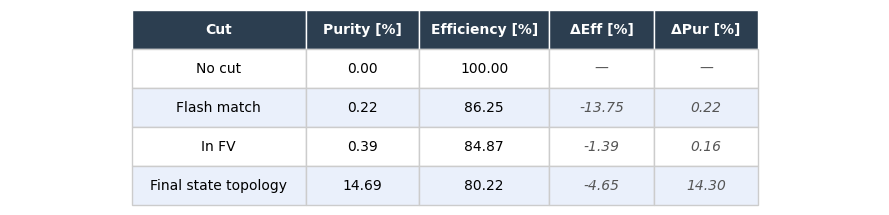

In [40]:
CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0,   pur_fm, pur_fv, pur_se]
effs_table  = [1.0,   eff_fm, eff_fv, eff_se]

fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

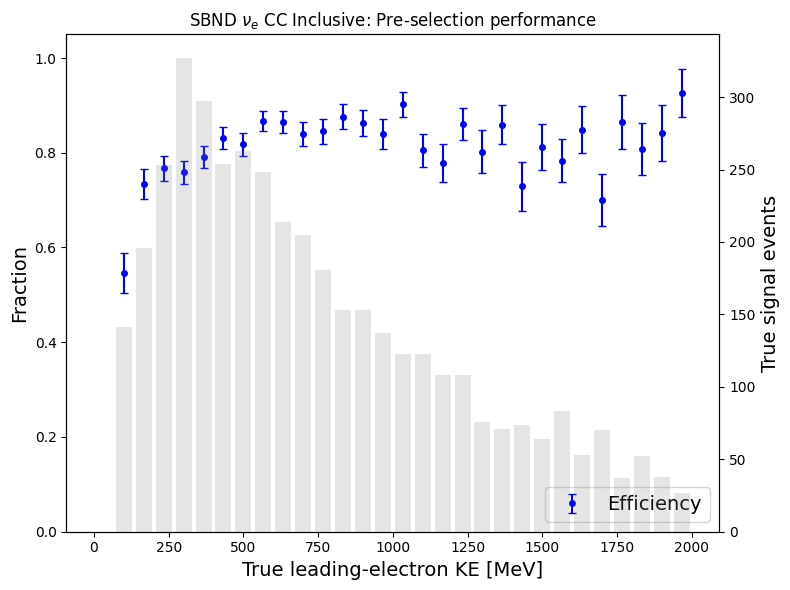

In [41]:
# ── Binned efficiency from truth_info (full pre-FM/FV universe) ──────────────
# FIX: build arrays from truth_info so the denominator = ALL true signal,
# not just the preselected subset stored in sel_topo.
# Non-presel events naturally get sel_mask=False (they never entered cut_flow).

# ke_bins_eff  = np.linspace(0, 200, 31)
ke_bins_eff  = np.linspace(0, 2000, 31)


all_true_ke  = truth_info["true_leading_e_ke"].fillna(-999).values
all_sig_mask = truth_info["is_true_signal"].values
all_sel_mask = truth_info.index.isin(                        # ← single_electron survivors
                   cut_flow["single_electron"]["inter_index"])

centers, purs_b, effs_b, counts_b = nh.pur_eff_binned(
    values   = all_true_ke,
    bins     = ke_bins_eff,
    sel_mask = all_sel_mask,
    sig_mask = all_sig_mask,          # full pre-FM/FV signal = correct denominator
)

n       = np.maximum(counts_b, 1)
eff_err = np.sqrt(effs_b * (1 - effs_b) / n)

fig_bin, ax_bin = plt.subplots(figsize=(8, 6))
ax2 = ax_bin.twinx()
ax_bin.errorbar(centers, effs_b, yerr=eff_err,
                fmt="o", color="blue", capsize=3, ms=4, label="Efficiency")
ax_bin.set_ylim(0, 1.05)
ax_bin.set_xlabel("True leading-electron KE [MeV]", fontsize=14)
ax_bin.set_ylabel("Fraction", fontsize=14)
ax_bin.set_title(fr"{TITLE}: Pre-selection performance")
ax_bin.legend(fontsize=14, loc="lower right")
ax2.bar(centers, counts_b,
        width=np.diff(centers).mean() * 0.8,
        alpha=0.2, color="gray", label="True signal")
ax2.set_ylabel("True signal events", fontsize=14)
plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_pur_ke_200MeV", fig=fig_bin, folder_name=PLOT_DIR)

In [42]:
# # ── Resolution plots from sel_topo ────────────────────────────────────────────
# ke_bins = np.linspace(0, 2000, 41)
# ct_bins = np.linspace(-1, 1,  41)

# # stage index: interactions that passed single_electron topology cut
# stage_idx = sel_topo.index[sel_topo["sel_single_electron"]]

# # signal-only mask (rows in sel_topo that are true signal)
# sig_mask = sel_topo["is_sig"]

# # ── KE resolution ─────────────────────────────────────────────────────────────
# fig_ke, _ = nh.plot_leading_e_resolution(
#     true_series = sel_topo.loc[sig_mask, "true_ke"],
#     reco_series = sel_topo.loc[sig_mask, "reco_ke"],
#     bins        = ke_bins,
#     stage_idx   = stage_idx,
#     xlabel      = "True leading electron KE [MeV]",
#     ylabel      = "Reco leading electron KE [MeV]",
#     normalize   = True,
#     log_color   = True,
#     title       = fr"{TITLE} — KE resolution",
# )
# plt.show()
# nh.save_plot("resolution_ke", fig=fig_ke, folder_name=PLOT_DIR)

# # ── cos θ resolution ───────────────────────────────────────────────────────────
# fig_ct, _ = nh.plot_leading_e_resolution(
#     true_series = sel_topo.loc[sig_mask, "true_costheta"],
#     reco_series = sel_topo.loc[sig_mask, "reco_costheta"],
#     bins        = ct_bins,
#     stage_idx   = stage_idx,
#     xlabel      = r"True leading electron $\cos\theta$",
#     ylabel      = r"Reco leading electron $\cos\theta$",
#     normalize   = False,
#     log_color   = True,
#     title       = fr"{TITLE} — $\cos\theta$ resolution",
# )
# plt.show()
# nh.save_plot("resolution_costheta", fig=fig_ct, folder_name=PLOT_DIR)

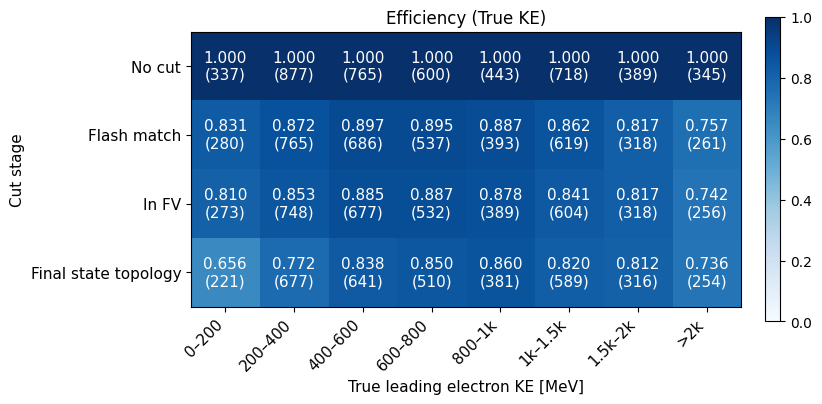

In [43]:
# ── Stage selection masks (aligned to truth_info index) ──────────────────────
stage_sel = {
    "precut"          : np.ones(len(truth_info), dtype=bool),
    "valid_flashmatch": truth_info["passed_fm"].values,
    "fiducial"        : truth_info["passed_presel"].values,
    "single_electron" : truth_info.index.isin(          # .isin() on Index → ndarray directly
                            cut_flow["single_electron"]["inter_index"]),
}
sig_true_vals = truth_info["is_true_signal"].values
n_cuts        = len(ns.CUT_NAMES)


# ── Efficiency matrix: true KE bins × cut stages ─────────────────────────────
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]

# ke_bins_c = np.array([0, 25, 50, 75, 100, 125, 150, 175, 200, np.inf])
# ke_bin_labels = [
#     "0–25", "25-50", "50-75", "75-100",
#     "100-125", "125-150", "150-175", "175-200", ">200",
# ]

n_ke_bins = len(ke_bins_c) - 1

ke_vals = truth_info["true_leading_e_ke"].fillna(-999).values

ke_eff_matrix   = np.zeros((n_ke_bins, n_cuts))
ke_count_matrix = np.zeros((n_ke_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals >= lo) & (ke_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        ke_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        ke_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    ke_eff_matrix, ke_count_matrix,
    bin_values       = np.arange(n_ke_bins),
    bin_labels       = ke_bin_labels,
    cut_labels       = ns.CUT_LABELS,
    remove_dummy_col = False,
    xlabel           = "True leading electron KE [MeV]",
    title            = "Efficiency (True KE)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke", fig=fig, folder_name=PLOT_DIR)


# # ── Efficiency matrix: true cos θ bins × cut stages ──────────────────────────
# ct_bins_c = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0,
#                         0.2,  0.4,  0.6,  0.8,  1.0])
# ct_bin_labels = [
#     "-1.0 - -0.8", "-0.8 - -0.6", "-0.6 - -0.4", "-0.4 - -0.2", "-0.2 - 0.0",
#     "0.0 - 0.2",   "0.2 - 0.4",   "0.4 - 0.6",   "0.6 - 0.8",   "0.8 - 1.0",
# ]
# n_ct_bins = len(ct_bins_c) - 1

# ct_vals = truth_info["true_leading_e_costheta"].fillna(-999).values

# ct_eff_matrix   = np.zeros((n_ct_bins, n_cuts))
# ct_count_matrix = np.zeros((n_ct_bins, n_cuts))

# for ci, cut_name in enumerate(ns.CUT_NAMES):
#     reco_sel = stage_sel[cut_name]
#     for i, (lo, hi) in enumerate(zip(ct_bins_c[:-1], ct_bins_c[1:])):
#         in_bin       = (ct_vals >= lo) & (ct_vals < hi)
#         sig_total    = (in_bin & sig_true_vals).sum()
#         sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
#         ct_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
#         ct_count_matrix[i, ci] = sig_selected

# fig, ax = nh.plot_matrix_binned(
#     ct_eff_matrix, ct_count_matrix,
#     bin_values       = np.arange(n_ct_bins),
#     bin_labels       = ct_bin_labels,
#     cut_labels       = ns.CUT_LABELS,
#     remove_dummy_col = False,
#     xlabel           = r"True leading electron $cos\theta$",
#     title            = r"Efficiency (True $cos\theta$)",
#     cmap             = "Blues",
# )
# fig.tight_layout()
# nh.save_plot("eff_matrix_true_costheta", fig=fig, folder_name=PLOT_DIR)


# # ── Efficiency matrix: true |p| bins × cut stages ────────────────────────────
# p_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
# p_bin_labels = [
#     "0–200", "200–400", "400–600", "600–800",
#     "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
# ]
# n_p_bins = len(p_bins_c) - 1

# p_vals = truth_info["true_leading_e_p"].fillna(-999).values

# p_eff_matrix   = np.zeros((n_p_bins, n_cuts))
# p_count_matrix = np.zeros((n_p_bins, n_cuts))

# for ci, cut_name in enumerate(ns.CUT_NAMES):
#     reco_sel = stage_sel[cut_name]
#     for i, (lo, hi) in enumerate(zip(p_bins_c[:-1], p_bins_c[1:])):
#         in_bin       = (p_vals >= lo) & (p_vals < hi)
#         sig_total    = (in_bin & sig_true_vals).sum()
#         sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
#         p_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
#         p_count_matrix[i, ci] = sig_selected

# fig, ax = nh.plot_matrix_binned(
#     p_eff_matrix, p_count_matrix,
#     bin_values       = np.arange(n_p_bins),
#     bin_labels       = p_bin_labels,
#     cut_labels       = ns.CUT_LABELS,
#     remove_dummy_col = False,
#     xlabel           = r"True leading electron $|p|$ [MeV/c]",
#     title            = "Efficiency (True momentnum)",
#     cmap             = "Blues",
# )
# fig.tight_layout()
# nh.save_plot("eff_matrix_true_p", fig=fig, folder_name=PLOT_DIR)

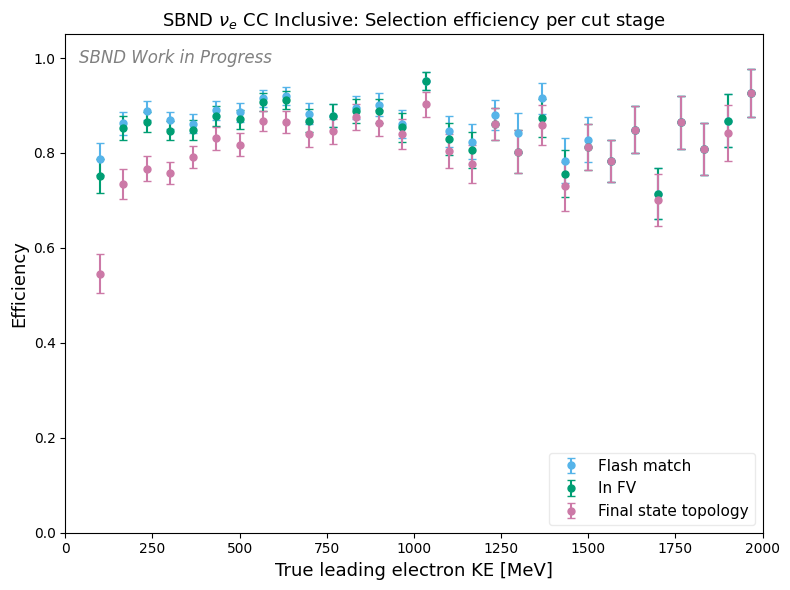

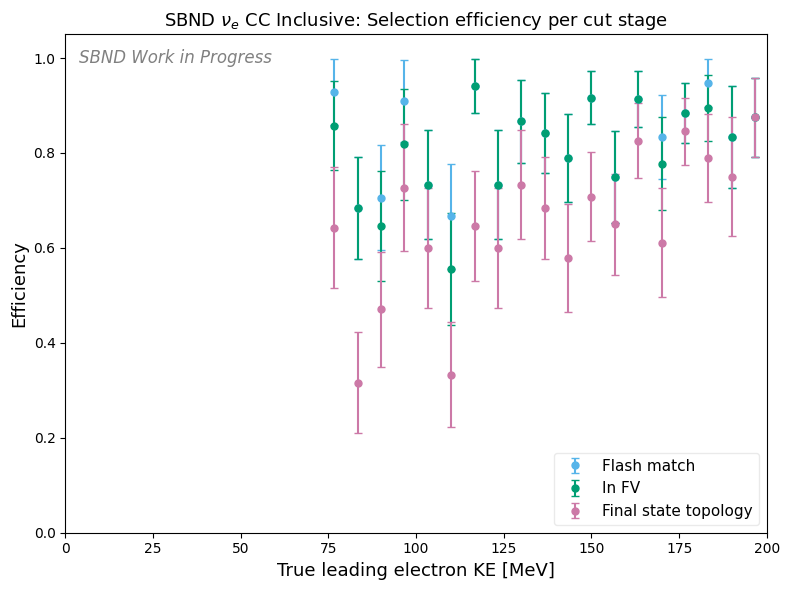

In [44]:
# ── Shared setup ─────────────────────────────────────────────────────────────
rp_df = nh.reco_particles(evtdf).df
tp_df = nh.true_particles(evtdf).df

def _col(df, name):
    if name in df.columns:       return name
    if (name, '') in df.columns: return (name, '')
    raise KeyError(f"'{name}' not found; first 20 cols: {list(df.columns)[:20]}")

rp_pid_col   = _col(rp_df, "pid")
tp_pid_col   = _col(tp_df, "pid")
tp_ke_col    = _col(tp_df, "ke")
_primary_col = next((c for c in ["is_primary", ("is_primary", "")]
                     if c in tp_df.columns), None)
tp_inter_idx = tp_df.index.droplevel(-1)

def _stage_to_inter(cname):
    """Interaction index for a given cut stage (evtdf = post-FM+FV baseline)."""
    if cname in ("precut", "valid_flashmatch", "fiducial"):
        return presel_inter
    if cname in cut_flow:
        return cut_flow[cname]["inter_index"]
    return presel_inter

def _pid_plot_title(pid_label, cname, clabel):
    """Human-readable title for PID fraction plot."""
    if cname == "precut":
        return f"True {pid_label} — No cut"
    return f"True {pid_label} — after {clabel} cut"

_palette = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#D55E00", "#0072B2"]
_markers = ["o",       "o",       "o",       "o",       "o",       "o"      ]

# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — Efficiency vs true KE, cut stages overlaid (no "no-cut" baseline)
# ══════════════════════════════════════════════════════════════════════════════
ke_bins_eff  = np.linspace(0, 2000, 31)
all_true_ke  = truth_info["true_leading_e_ke"].fillna(-999).values
all_sig_mask = truth_info["is_true_signal"].values

fig_eff, ax_eff = plt.subplots(figsize=(8, 6))

for (cname, clabel), color, marker in zip(
        zip(ns.CUT_NAMES, ns.CUT_LABELS), _palette, _markers):

    if cname == "precut":          # skip "no cut" baseline
        continue

    centers, _, effs_b, counts_b = nh.pur_eff_binned(
        values   = all_true_ke,
        bins     = ke_bins_eff,
        sel_mask = stage_sel[cname],
        sig_mask = all_sig_mask,
    )
    eff_err = np.sqrt(effs_b * (1 - effs_b) / np.maximum(counts_b, 1))
    ax_eff.errorbar(centers, effs_b, yerr=eff_err,
                    fmt=marker, color=color, capsize=3, ms=5,
                    lw=1.5, label=clabel)

ax_eff.set_ylabel("Efficiency", fontsize=13)
ax_eff.set_xlabel("True leading electron KE [MeV]", fontsize=13)
ax_eff.set_ylim(0, 1.05)
ax_eff.set_xlim(ke_bins_eff[0], ke_bins_eff[-1])
ax_eff.legend(fontsize=11, loc="lower right", framealpha=0.4)
ax_eff.set_title(fr"{TITLE}: Selection efficiency per cut stage", fontsize=13)
ax_eff.text(0.02, 0.97, "SBND Work in Progress",
            transform=ax_eff.transAxes, fontsize=12, color="gray",
            va="top", style="italic")

plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_all_stages", fig=fig_eff, folder_name=PLOT_DIR)


# ══════════════════════════════════════════════════════════════════════════════
ke_bins_eff  = np.linspace(0, 200, 31)
all_true_ke  = truth_info["true_leading_e_ke"].fillna(-999).values
all_sig_mask = truth_info["is_true_signal"].values

fig_eff, ax_eff = plt.subplots(figsize=(8, 6))

for (cname, clabel), color, marker in zip(
        zip(ns.CUT_NAMES, ns.CUT_LABELS), _palette, _markers):

    if cname == "precut":          # skip "no cut" baseline
        continue

    centers, _, effs_b, counts_b = nh.pur_eff_binned(
        values   = all_true_ke,
        bins     = ke_bins_eff,
        sel_mask = stage_sel[cname],
        sig_mask = all_sig_mask,
    )
    eff_err = np.sqrt(effs_b * (1 - effs_b) / np.maximum(counts_b, 1))
    ax_eff.errorbar(centers, effs_b, yerr=eff_err,
                    fmt=marker, color=color, capsize=3, ms=5,
                    lw=1.5, label=clabel)

ax_eff.set_ylabel("Efficiency", fontsize=13)
ax_eff.set_xlabel("True leading electron KE [MeV]", fontsize=13)
ax_eff.set_ylim(0, 1.05)
ax_eff.set_xlim(ke_bins_eff[0], ke_bins_eff[-1])
ax_eff.legend(fontsize=11, loc="lower right", framealpha=0.4)
ax_eff.set_title(fr"{TITLE}: Selection efficiency per cut stage", fontsize=13)
ax_eff.text(0.02, 0.97, "SBND Work in Progress",
            transform=ax_eff.transAxes, fontsize=12, color="gray",
            va="top", style="italic")

plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_all_stages_lowKE", fig=fig_eff, folder_name=PLOT_DIR)

### 4-2. Histograms

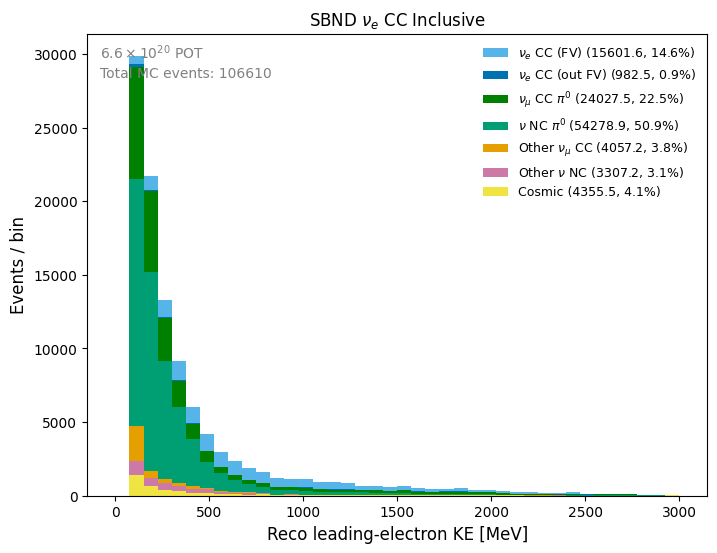

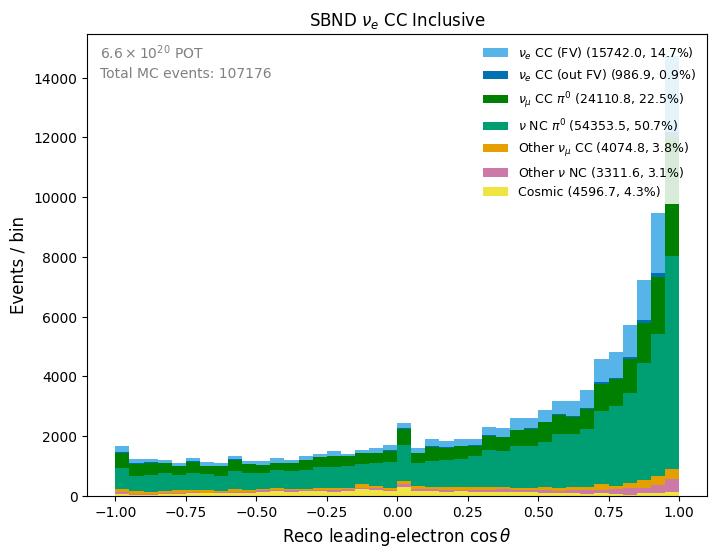

In [45]:
# ── Topology stacked histograms from sel_topo ─────────────────────────────────
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]

def _topo_cat(col, cat):
    mask = sel_topo["sel_single_electron"] & (sel_topo["truth_cat"] == cat)
    return sel_topo.loc[mask, col].dropna().values

_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 3000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke", fig=fig_ke, folder_name=PLOT_DIR)

fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta", fig=fig_cos, folder_name=PLOT_DIR)

## 5. Shower quality cuts

In [46]:
import nue_helpers as nh
import nue_selection as ns

# truth_cat_presel already computed from truth_info in cell 4 — use directly
truth_cats = truth_cat_presel   # replaces: ns.classify_truth(evtdf, verbose=False)



/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


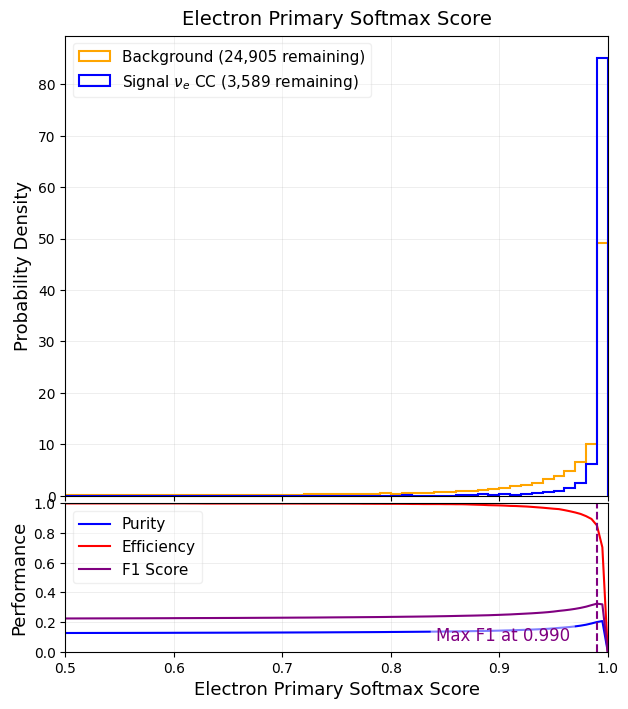


──────────────────────────────────────────────────
  Variable   : primary_scores
  Remaining  : 28,494 interactions (3589 signal, 24905 bkg)
  Cut dir    : > 0.9900
  Efficiency : 85.1%  (of remaining signal)
  Purity     : 20.0%
  Max F1     : 0.3237
──────────────────────────────────────────────────



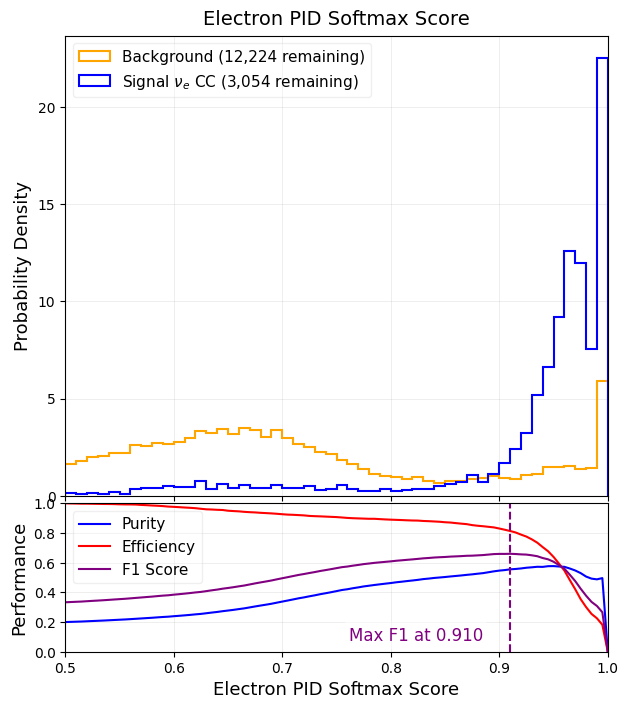


──────────────────────────────────────────────────
  Variable   : pid_scores
  Remaining  : 15,278 interactions (3054 signal, 12224 bkg)
  Cut dir    : > 0.9100
  Efficiency : 81.3%  (of remaining signal)
  Purity     : 55.5%
  Max F1     : 0.6598
──────────────────────────────────────────────────



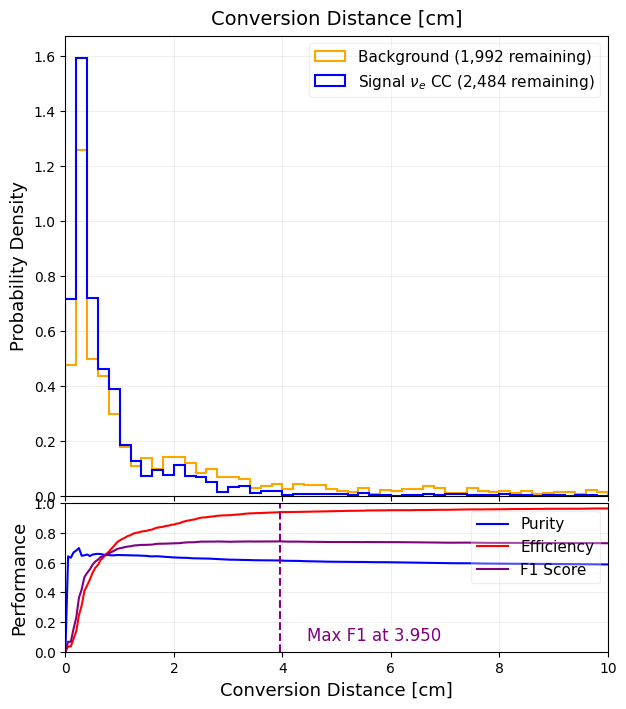


──────────────────────────────────────────────────
  Variable   : vertex_distance
  Remaining  : 4,476 interactions (2484 signal, 1992 bkg)
  Cut dir    : < 3.9500
  Efficiency : 94.0%  (of remaining signal)
  Purity     : 61.5%
  Max F1     : 0.7435
──────────────────────────────────────────────────



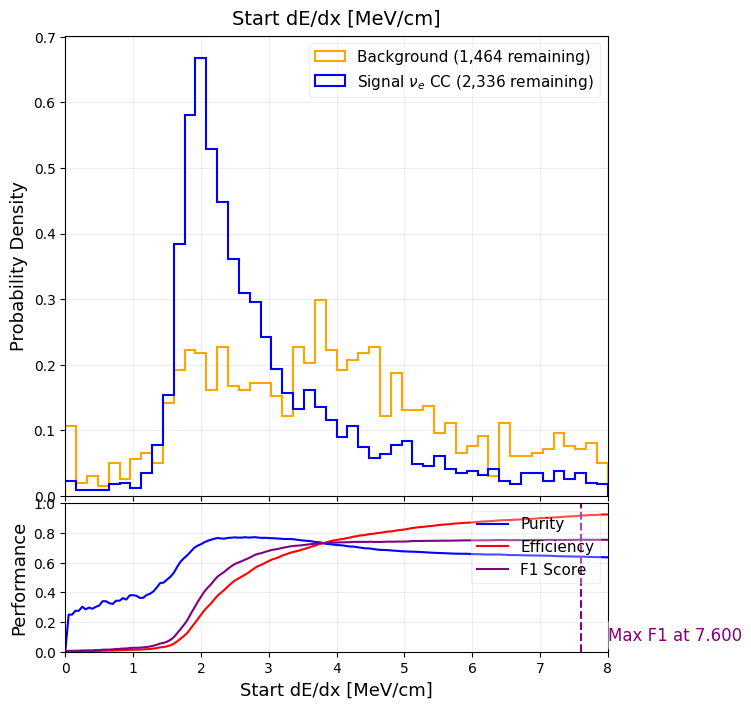


──────────────────────────────────────────────────
  Variable   : start_dedx
  Remaining  : 3,800 interactions (2336 signal, 1464 bkg)
  Cut dir    : < 7.6000
  Efficiency : 91.7%  (of remaining signal)
  Purity     : 64.1%
  Max F1     : 0.7544
──────────────────────────────────────────────────



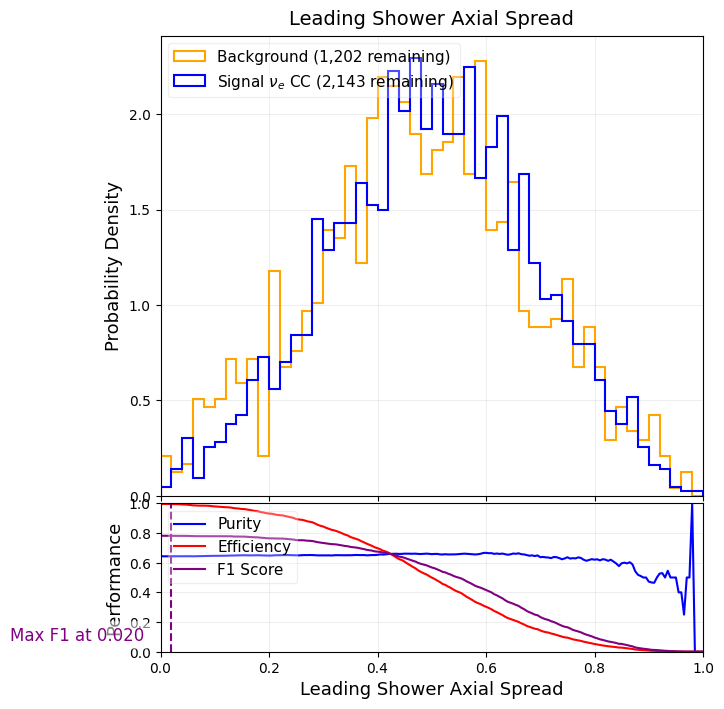


──────────────────────────────────────────────────
  Variable   : axial_spread
  Remaining  : 3,345 interactions (2143 signal, 1202 bkg)
  Cut dir    : > 0.0200
  Efficiency : 99.5%  (of remaining signal)
  Purity     : 64.4%
  Max F1     : 0.7815
──────────────────────────────────────────────────



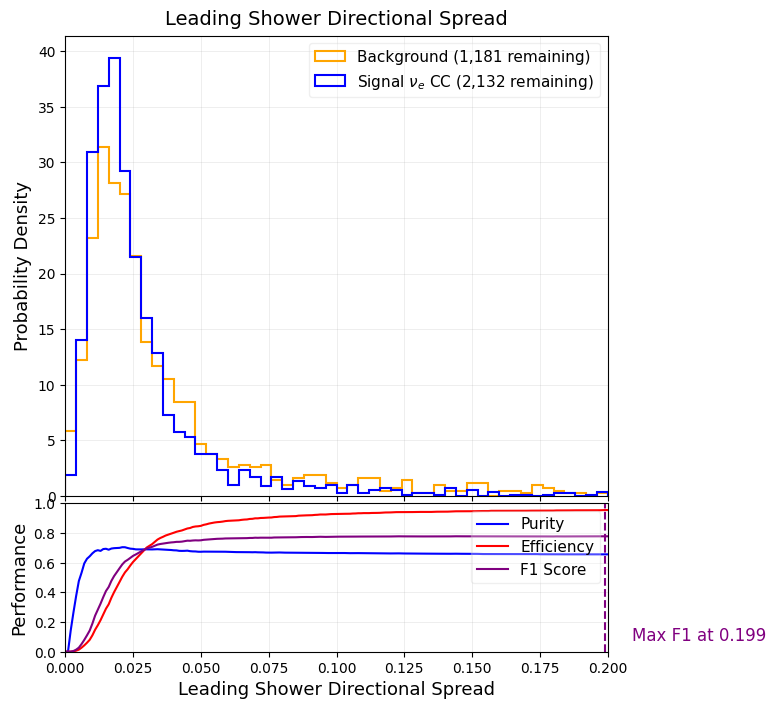


──────────────────────────────────────────────────
  Variable   : directional_spread
  Remaining  : 3,313 interactions (2132 signal, 1181 bkg)
  Cut dir    : < 0.1990
  Efficiency : 95.5%  (of remaining signal)
  Purity     : 65.6%
  Max F1     : 0.7778
──────────────────────────────────────────────────


Final surviving interactions: 3,101

Optimal thresholds (cumulative):
  primary_scores                : 0.9900
  pid_scores                    : 0.9100
  vertex_distance               : 3.9500
  start_dedx                    : 7.6000
  axial_spread                  : 0.0200
  directional_spread            : 0.1990


In [47]:
import nue_helpers as nh

shower_cuts = [
    ("primary_scores",     [0.5, 1.0], "Electron Primary Softmax Score",     [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_primary_score"),
    ("pid_scores",         [0.5, 1.0], "Electron PID Softmax Score",        [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_pid_score"),
    ("vertex_distance",    [0.0, 10.], "Conversion Distance [cm]",           [0.0, 10.0, 0.05],  '<',  'right', "f1_thrsh_vertex_distance"),
    ("start_dedx",         [0.0, 8.0], "Start dE/dx [MeV/cm]",              [0.0, 8.0,  0.05],  '<',  'right', "f1_thrsh_start_dedx"),
    ("axial_spread",       [0.0, 1.0], "Leading Shower Axial Spread",        [0.0, 1.0,  0.005], '>',  'left',  "f1_thrsh_axial_spread"),
    ("directional_spread", [0.0, 0.2], "Leading Shower Directional Spread",  [0.0, 0.2,  0.001], '<',  'right', "f1_thrsh_directional_spread"),
]

# opt_thresholds = {}
# for col, bounds, xlabel, trange, cdir, lloc, sname in shower_cuts:
#     opt_t, opt_f1 = nh.threshold_plots(
#         evtdf            = evtdf,
#         cut_flow_result  = cut_flow,
#         cut_stage        = "single_electron",
#         metric_col       = col,
#         bounds           = bounds,
#         xaxis_name       = xlabel,
#         plot_title       = f"{xlabel} — threshold scan",
#         threshold_range  = trange,
#         cut_dir          = cdir,
#         legend_loc       = lloc,
#         truth_categories = truth_cats,
#         save_name        = sname,
#         plot_folder      = PLOT_DIR,
#     )
#     opt_thresholds[col] = opt_t

# print("\nOptimal thresholds summary:")
# for k, v in opt_thresholds.items():
#     print(f"  {k:<30s}: {v:.4f}")

opt_thresholds_cumulative = nh.threshold_plots_cumulative(
    evtdf            = evtdf,
    cut_flow_result  = cut_flow,
    cut_stage        = "single_electron",
    shower_cuts      = shower_cuts,
    truth_categories = truth_cats,
    plot_folder      = PLOT_DIR,
)

print("\nOptimal thresholds (cumulative):")
for k, v in opt_thresholds_cumulative.items():
    print(f"  {k:<30s}: {v:.4f}")

In [59]:
import gc

# ── Shower quality cuts (still needs evtdf — particle-level scores) ───────────
cut_flow_sq = ns.shower_qual_cuts(evtdf)

# ── Build stage index dict ────────────────────────────────────────────────────
_stage_idx_qual = {
    "precut"          : truth_info.index,
    "valid_flashmatch": truth_info.index[truth_info["passed_fm"]],
    "fiducial"        : truth_info.index[truth_info["passed_presel"]],
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_qual:
        _stage_idx_qual[_name] = cut_flow_sq[_name]["inter_index"]

# ── Save per-interaction shower scores for future threshold fine-tuning ───────
# These are the only columns we still need evtdf for after this cell.
# Saving them here means future re-runs only need sel_qual.df, not evtdf.
_score_cols = ["primary_scores", "pid_scores",
               "vertex_distance", "directional_spread",
               "axial_spread", "start_dedx"]
_il = nh.inter_levels(evtdf)
rp_df = nh.reco_particles(evtdf)._df

# leading electron per interaction for each score column
_pid_col = ('pid', '') if ('pid', '') in rp_df.columns else 'pid'
_ke_col  = ('ke',  '') if ('ke',  '') in rp_df.columns else 'ke'
_ele_df  = rp_df[rp_df[_pid_col] == nh.PID_ELECTRON]
_lead_i  = _ele_df[_ke_col].groupby(level=_il).idxmax().dropna()
_lead_ele = _ele_df.loc[_lead_i].copy()
_lead_ele.index = _lead_ele.index.droplevel(-1)

extra_scores = {}
for _sc in _score_cols:
    _col = (_sc, '') if (_sc, '') in _lead_ele.columns else _sc
    if _col in _lead_ele.columns:
        extra_scores[_sc] = _lead_ele[_col].reindex(presel_inter)

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

In [60]:
# ── Build and save sel_qual ───────────────────────────────────────────────────
# reco/true columns reused from sel_topo — no re-extraction from evtdf needed
os.makedirs(DF_OUT_DIR, exist_ok=True)
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual.df")
sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = sel_topo["reco_ke"],       # ← from sel_topo, not evtdf
    reco_cos         = sel_topo["reco_costheta"], # ← from sel_topo, not evtdf
    reco_p           = sel_topo["reco_p"],
    true_ke          = sel_topo["true_ke"],       # ← from sel_topo, not evtdf
    true_cos         = sel_topo["true_costheta"], # ← from sel_topo, not evtdf
    true_p           = sel_topo["true_p"],
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
    # extra_cols       = extra_scores,              # ← score columns for re-tuning
)


Saved selection df → ./nuecc_dfs/selected_nuecc_qual.df
  shape=(980816, 16)  size=22.8 MB


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


Building: No cut ... 

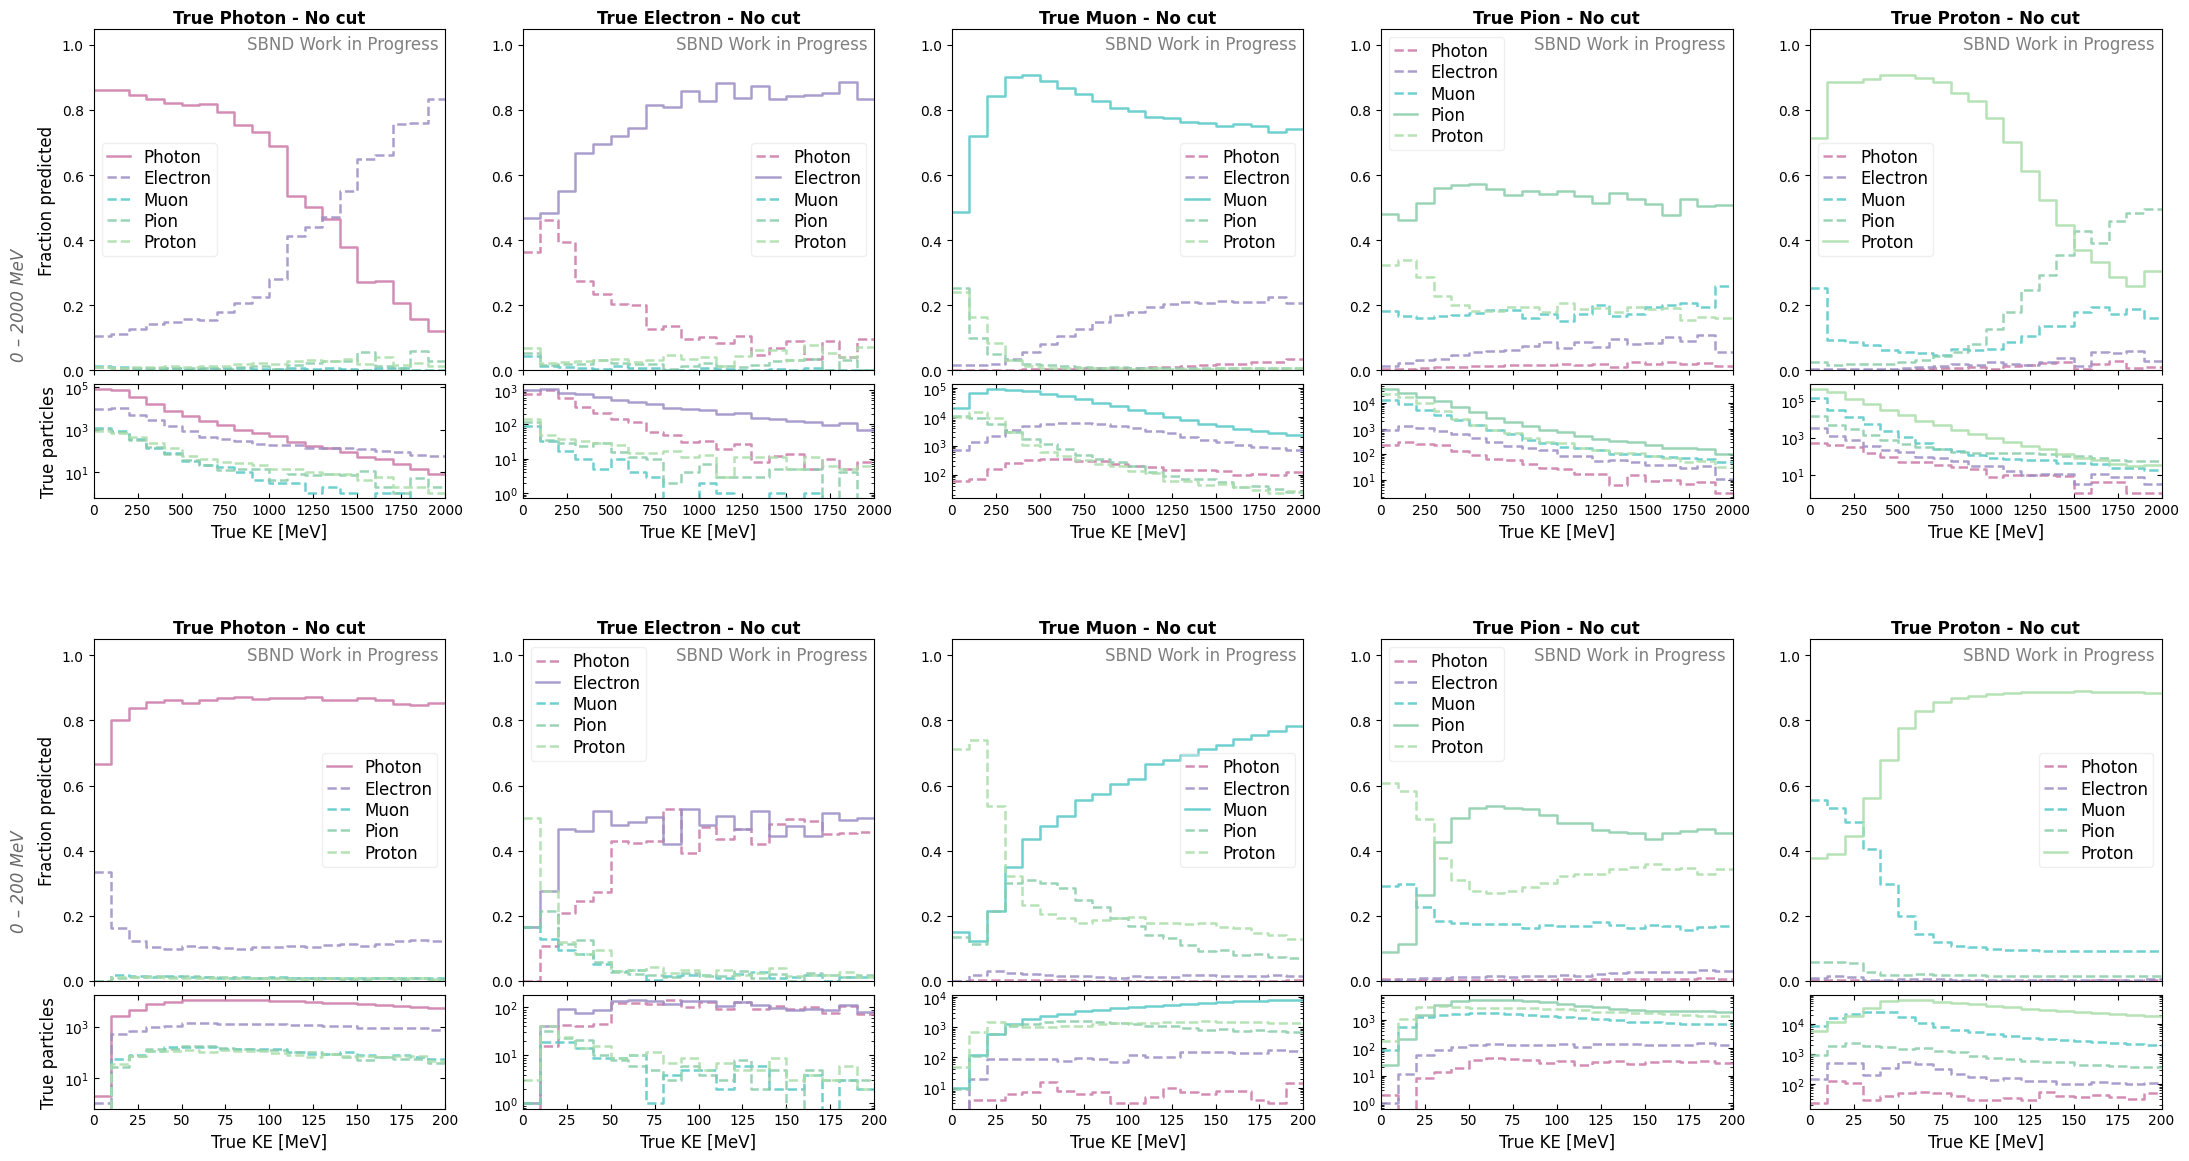

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after Flash match cut ... 

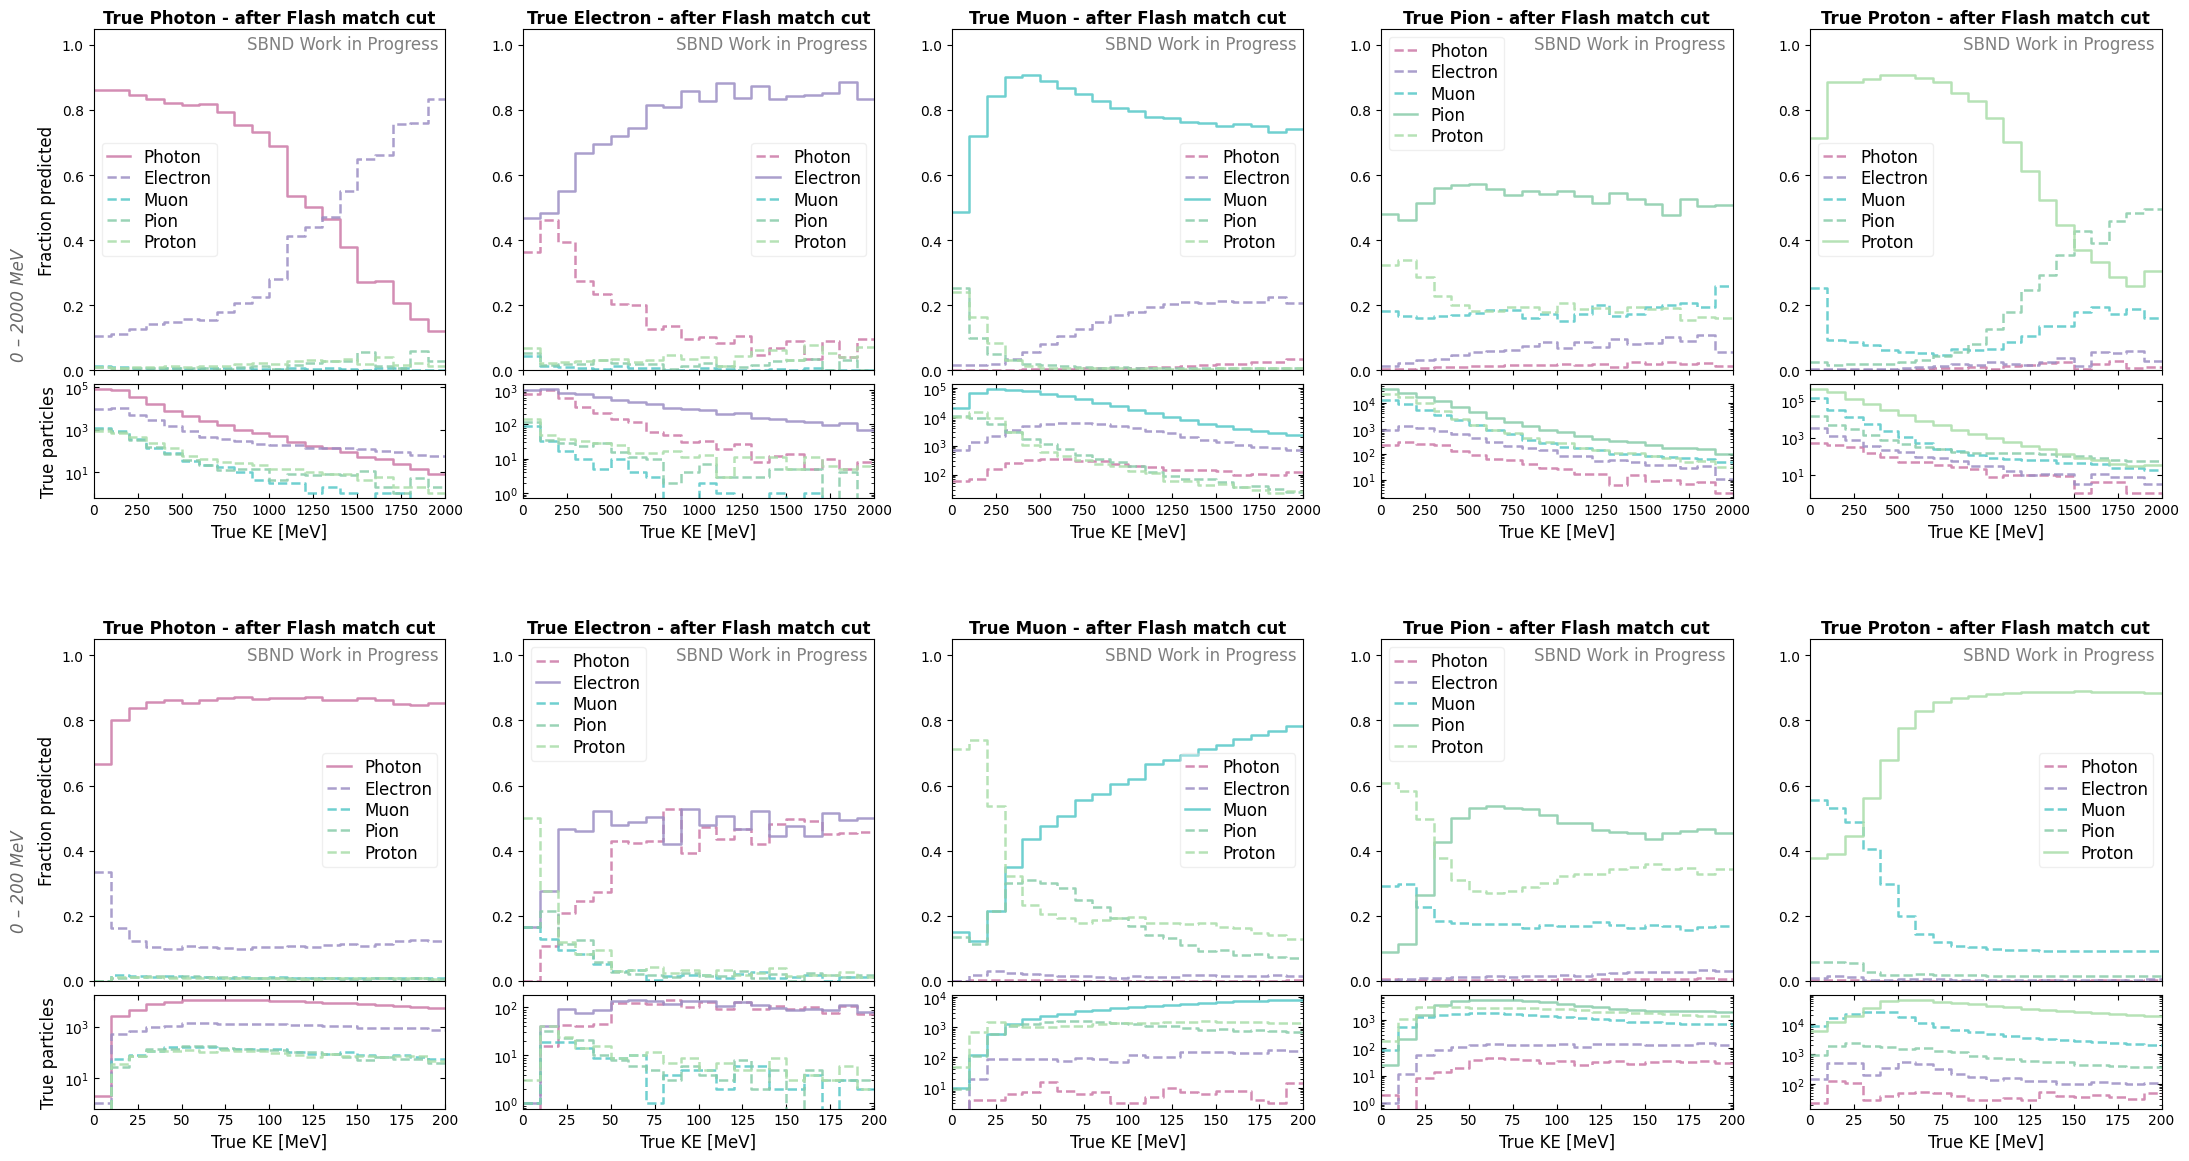

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after In FV cut ... 

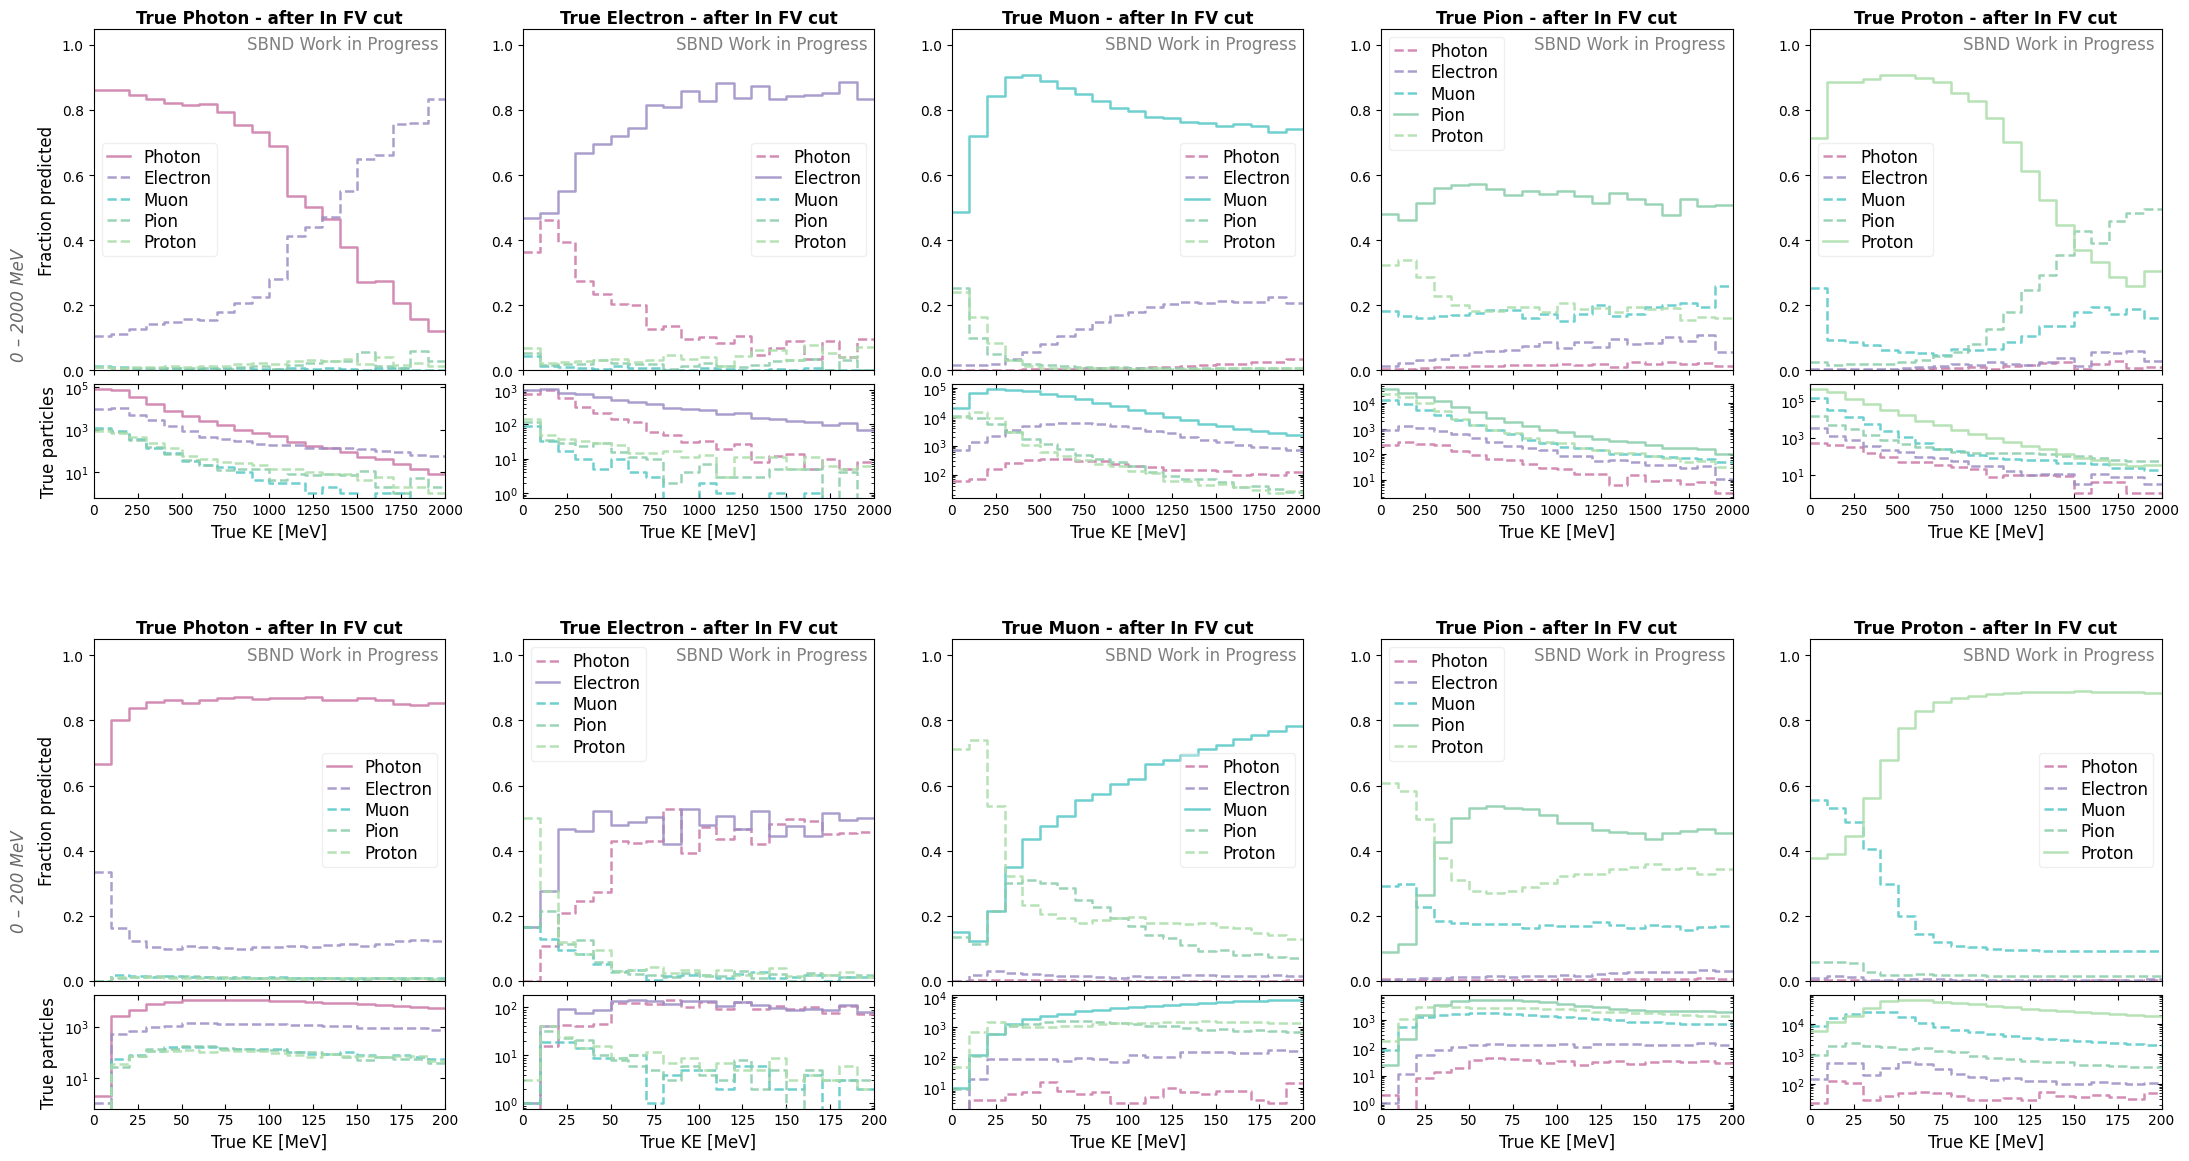

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after Final state topology cut ... 

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1371: RuntimeWarning: invalid value encountered in divide
  fracs = np.where(total_per_bin > 0, counts / total_per_bin, 0.0)


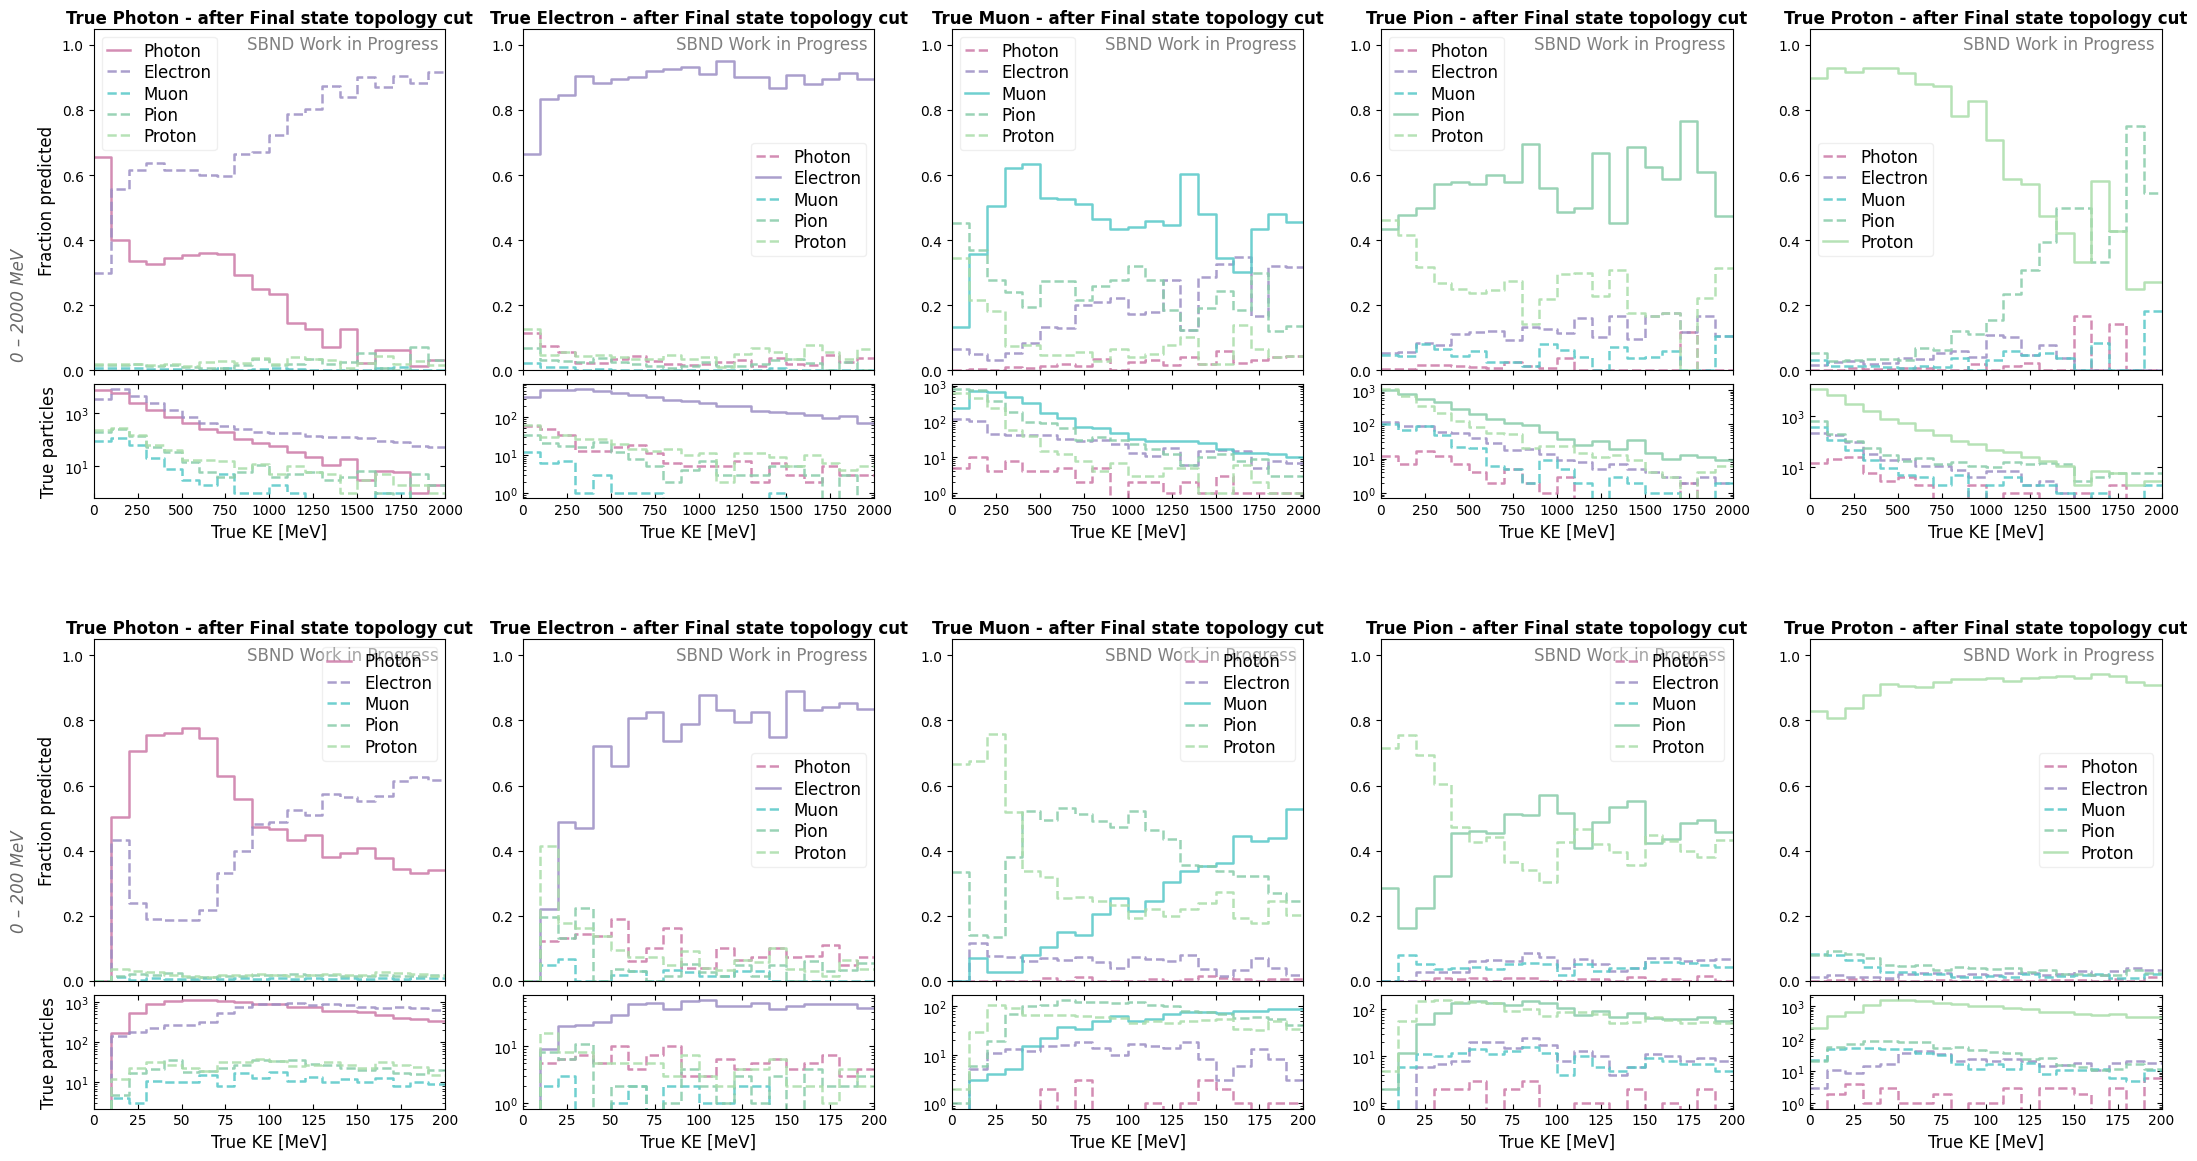

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after Electron primary score cut ... 

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1371: RuntimeWarning: invalid value encountered in divide
  fracs = np.where(total_per_bin > 0, counts / total_per_bin, 0.0)


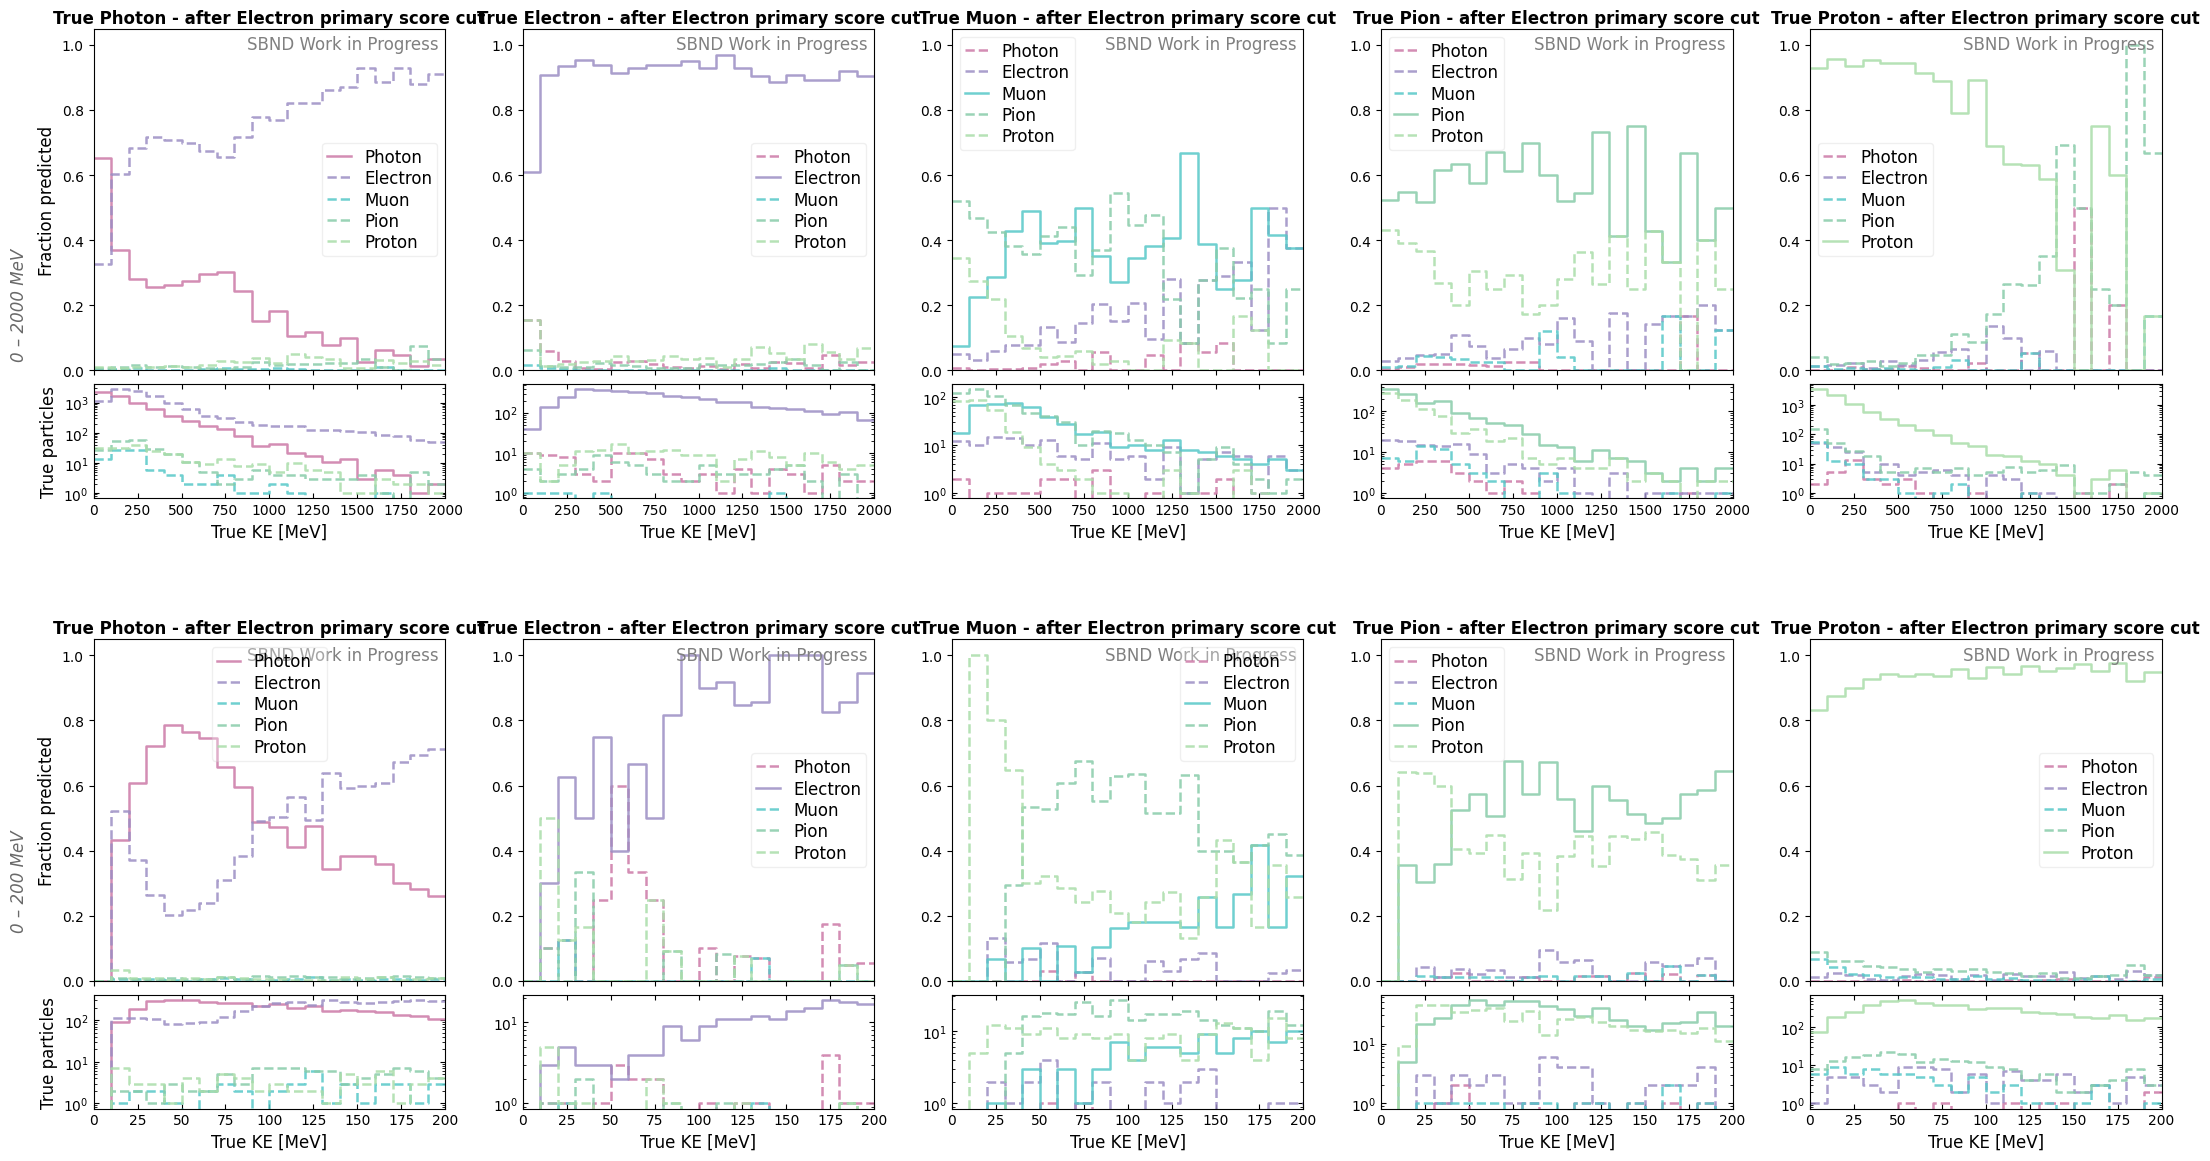

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after Electron PID score cut ... 

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1371: RuntimeWarning: invalid value encountered in divide
  fracs = np.where(total_per_bin > 0, counts / total_per_bin, 0.0)


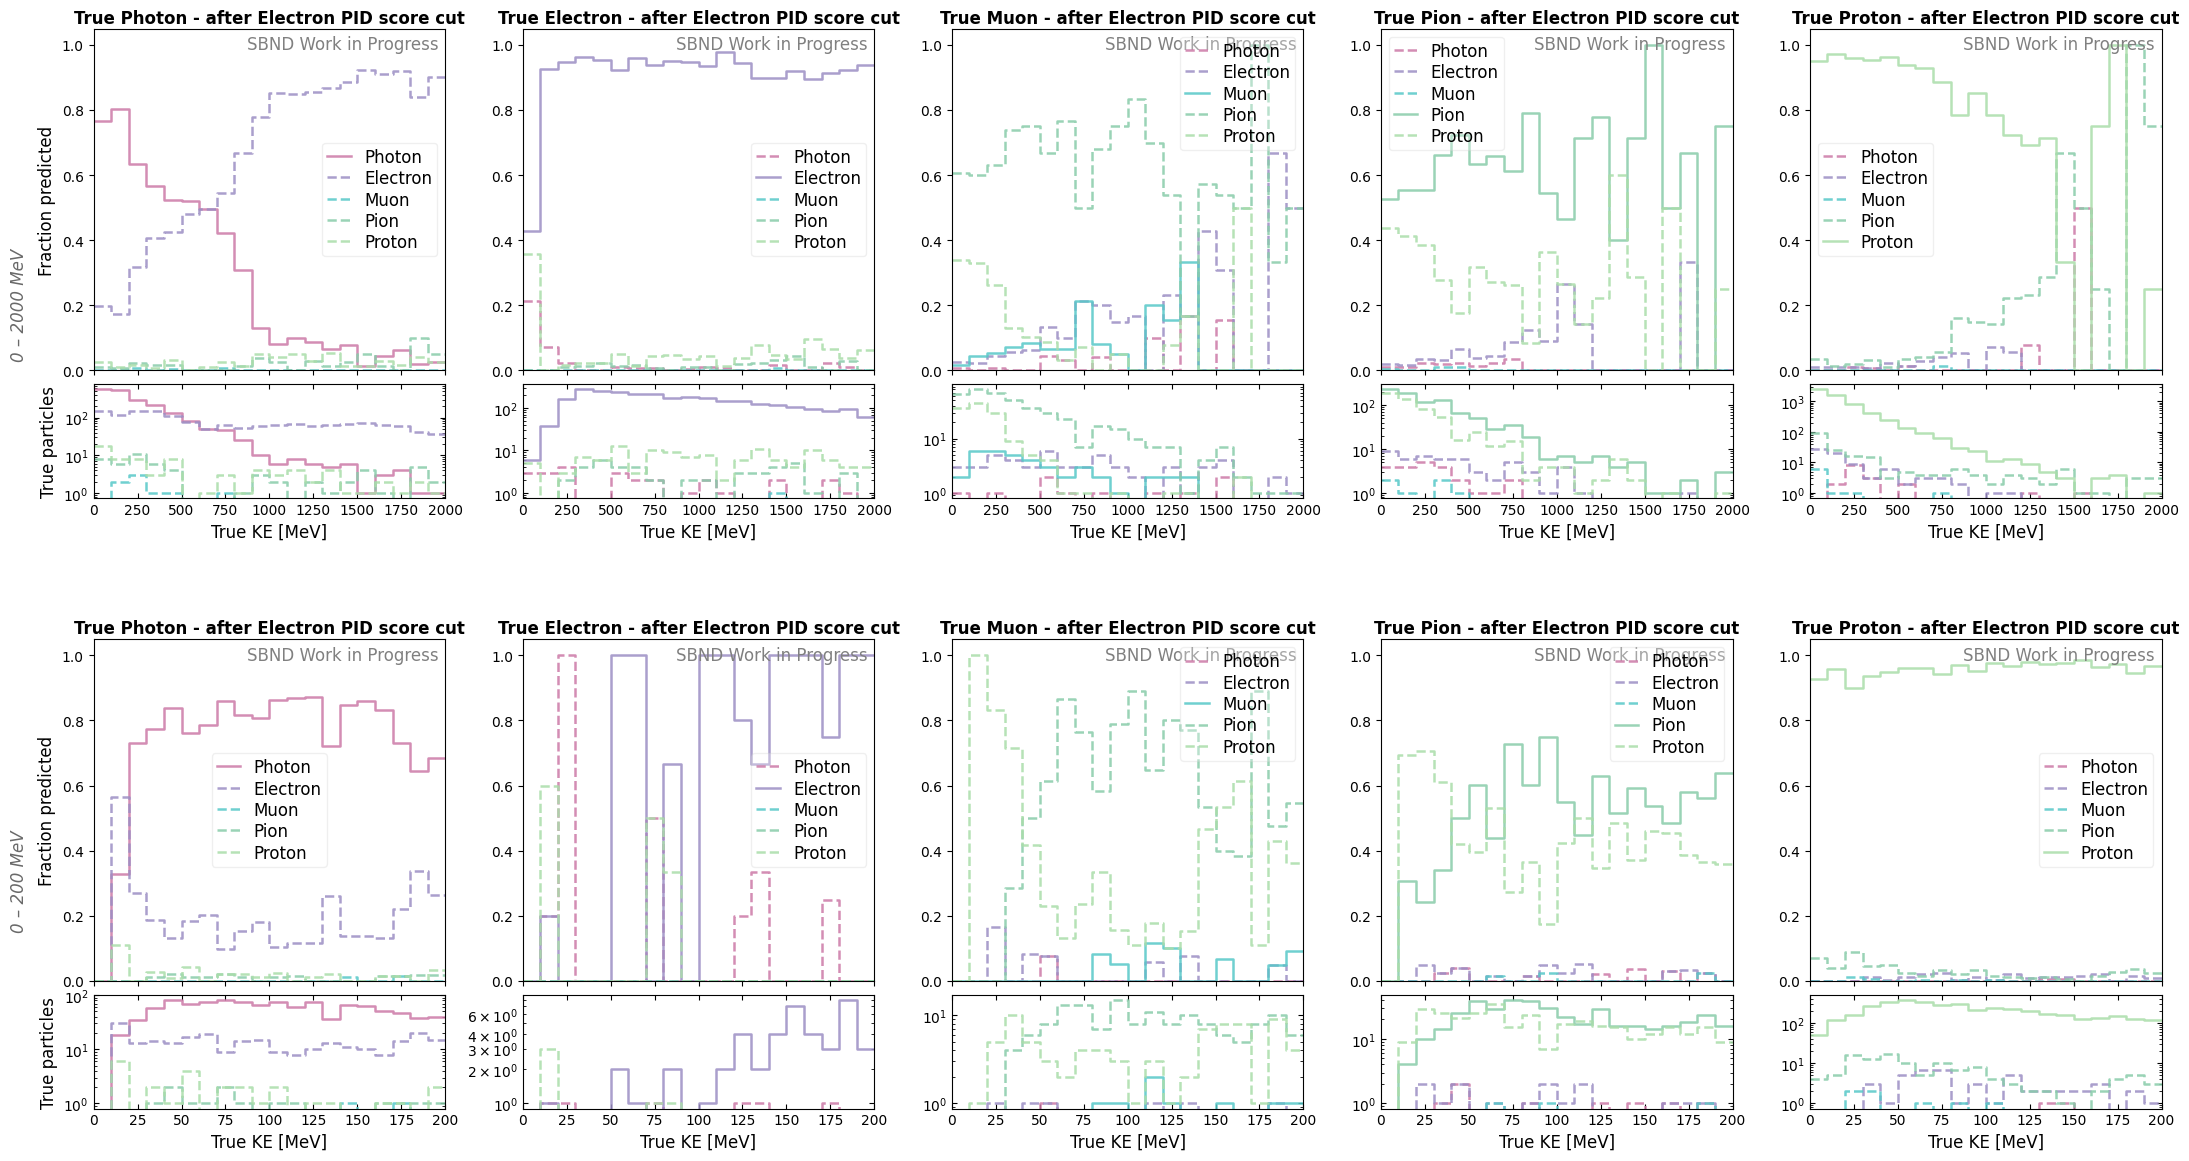

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.
Building: after Conversion gap cut ... 

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1371: RuntimeWarning: invalid value encountered in divide
  fracs = np.where(total_per_bin > 0, counts / total_per_bin, 0.0)


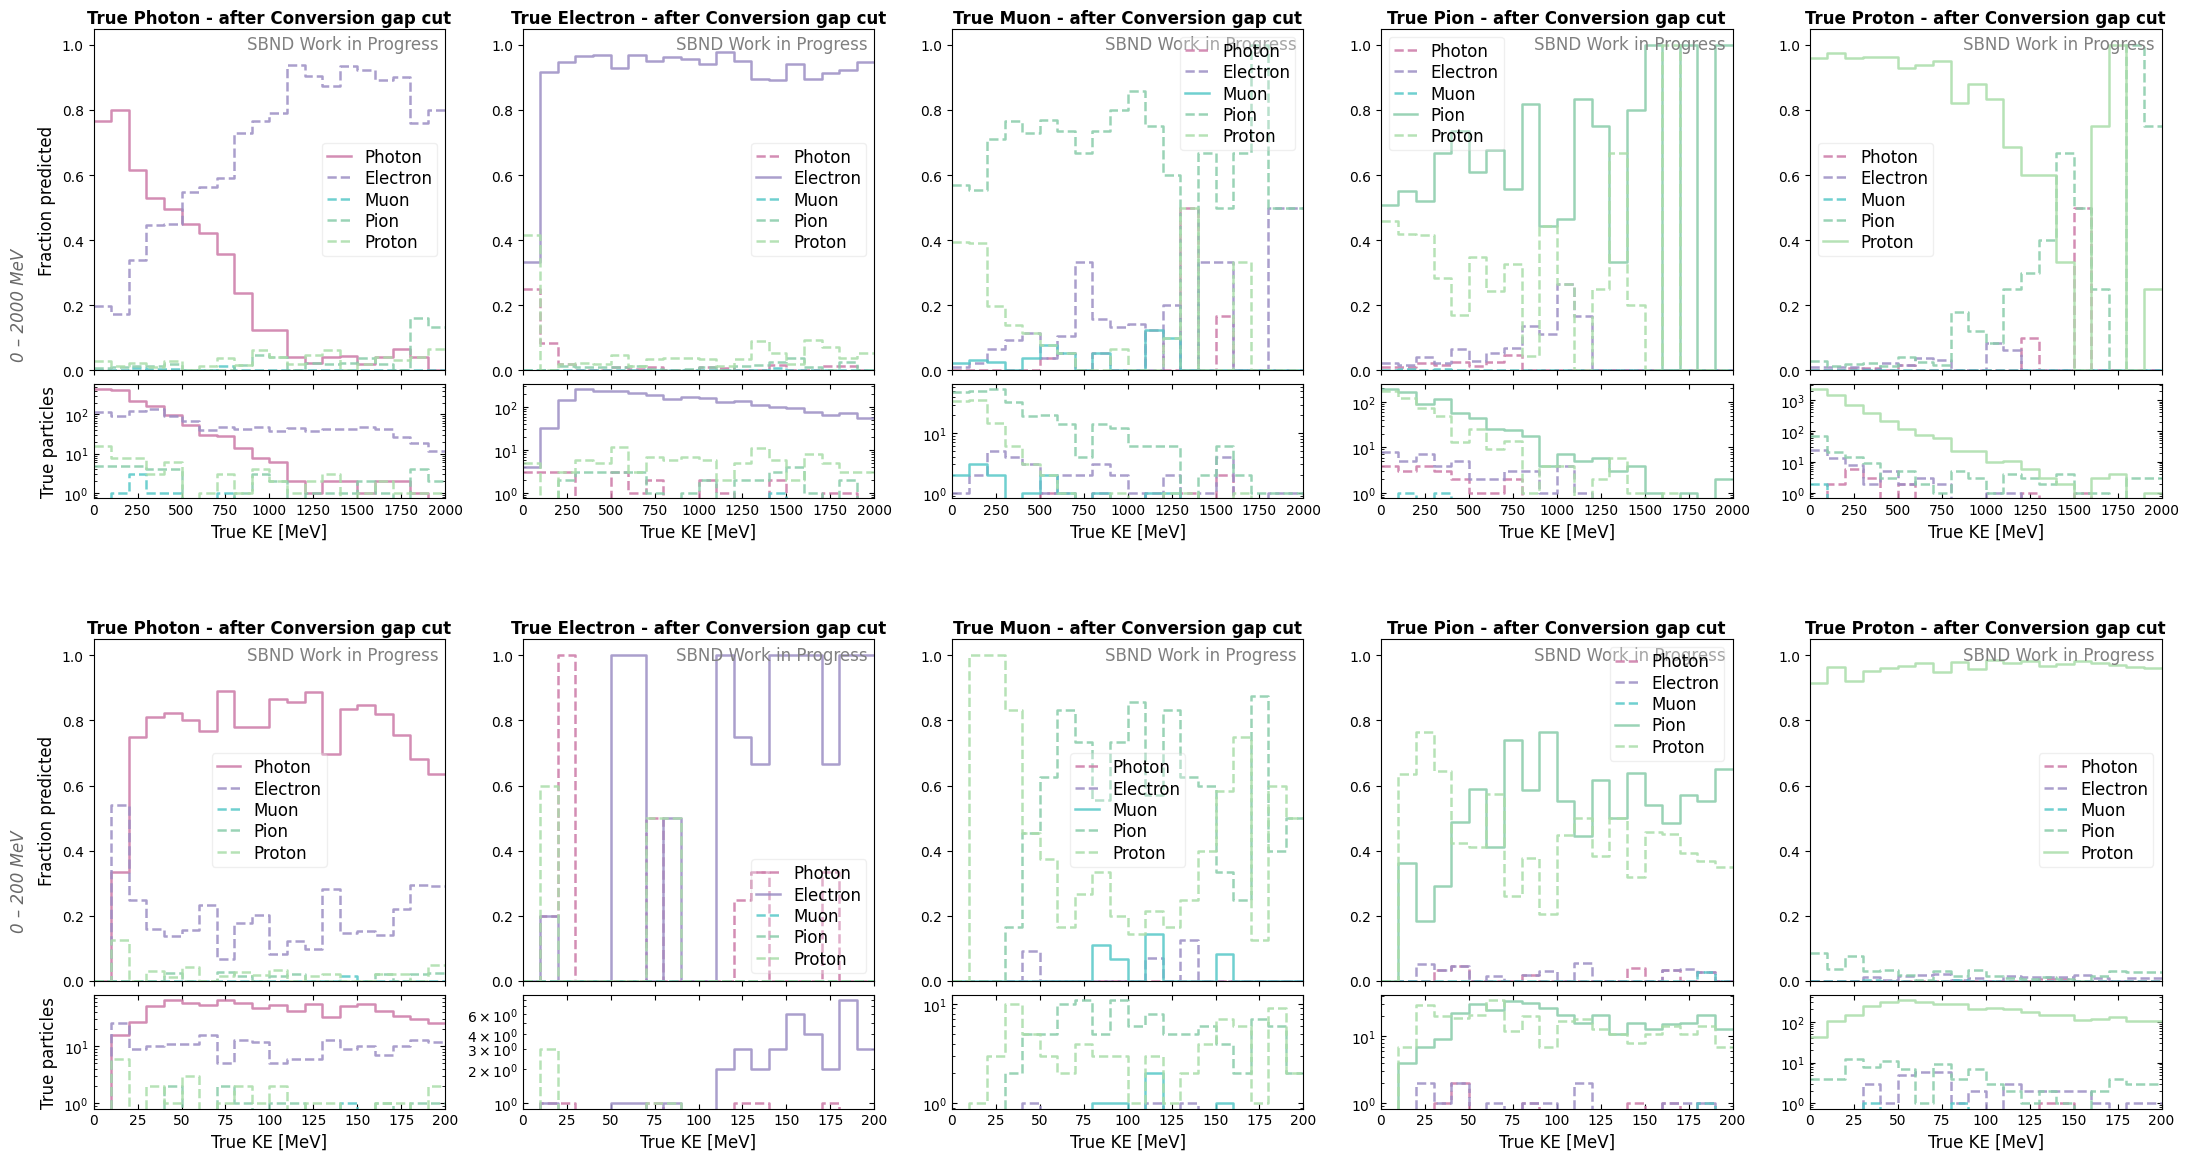

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1665: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved.


In [61]:
from matplotlib.gridspec import GridSpec

rp_df = nh.reco_particles(evtdf).df
tp_df = nh.true_particles(evtdf).df

def _col(df, name):
    if name in df.columns:       return name
    if (name, '') in df.columns: return (name, '')
    raise KeyError(f"'{name}' not found")

rp_pid_col   = _col(rp_df, "pid")
tp_pid_col   = _col(tp_df, "pid")
tp_ke_col    = _col(tp_df, "ke")
_primary_col = next((c for c in ["is_primary", ("is_primary", "")]
                     if c in tp_df.columns), None)
tp_inter_idx = tp_df.index.droplevel(-1)

KE_FULL = np.linspace(0, 2000, 21)
KE_LOW  = np.linspace(0,  200, 21)

def _collect_all_particles(stage_inter):
    """Return list of (true_ke, reco_pid, pid_val, pid_label) for all 5 species."""
    out = []
    for pid_val in sorted(nh.PID_NAMES.keys()):
        in_stage  = tp_inter_idx.isin(stage_inter)
        is_target = (tp_df[tp_pid_col] == pid_val) & in_stage
        if _primary_col is not None:
            is_target &= tp_df[_primary_col].astype(bool)
        subset = tp_df[is_target]
        reco   = rp_df[rp_pid_col].reindex(subset.index, fill_value=-1)
        out.append((subset[tp_ke_col].values, reco.values,
                    pid_val, nh.PID_NAMES[pid_val]))
    return out

def _build_combined_fig(particle_data, cut_title, title_fs=12):
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

    fig = plt.figure(figsize=(22, 12))   # slightly wider for 5 cols

    # ── Outer: 2 rows (one per KE range) with an explicit inter-group gap ────
    outer = GridSpec(
        2, 1, figure=fig,
        hspace   = 0.30,        # gap BETWEEN the full-KE and low-KE halves
        top      = 0.96,
        bottom   = 0.06,
        left     = 0.045,
        right    = 0.985,
    )

    # ── Inner: fraction + counts rows, 5 particle columns ────────────────────
    _inner_kw = dict(height_ratios=[3, 1.0], hspace=0.06, wspace=0.22)
    gs_top = GridSpecFromSubplotSpec(2, 5, subplot_spec=outer[0], **_inner_kw)
    gs_bot = GridSpecFromSubplotSpec(2, 5, subplot_spec=outer[1], **_inner_kw)

    for col, (true_ke, reco_pid, pid_val, pid_label) in enumerate(particle_data):
        for ke_bins, gs in [(KE_FULL, gs_top), (KE_LOW, gs_bot)]:
            ax_frac  = fig.add_subplot(gs[0, col])
            ax_count = fig.add_subplot(gs[1, col])

            nh.plot_pid_fraction_vs_ke(
                true_ke              = true_ke,
                reco_pid             = reco_pid,
                ke_bins              = ke_bins,
                true_pid_target_name = f"True {pid_label} - {cut_title}",
                highlight_pid        = pid_val,
                title_fontsize       = title_fs,
                ax1                  = ax_frac,
                ax2                  = ax_count,
            )

            # Override legend: move to lower-left to avoid overlap with title
            ax_frac.legend(fontsize=12, loc="best", framealpha=0.3,
                           handlelength=1.4, labelspacing=0.2, borderpad=0.3)

            if col > 0:           # suppress redundant y-labels on cols 1-4
                ax_frac.set_ylabel("")
                ax_count.set_ylabel("")

    # KE-range group labels on the left margin
    fig.text(0.007, 0.73, "0 – 2000 MeV", va="center", rotation=90,
             fontsize=12, color="dimgray", style="italic")
    fig.text(0.007, 0.25, "0 – 200 MeV",  va="center", rotation=90,
             fontsize=12, color="dimgray", style="italic")
    return fig

# ── Define all cut stages ─────────────────────────────────────────────────────
# (cname, display_title, interaction_index, title_fontsize)
def _inter(cname):
    if cname in ("precut", "valid_flashmatch", "fiducial"): return presel_inter
    if cname in cut_flow:                                    return cut_flow[cname]["inter_index"]
    if cname in _stage_idx_qual:                             return _stage_idx_qual[cname]
    return presel_inter

presel_stages = [
    ("precut",           "No cut",                        presel_inter,                    12),
    ("valid_flashmatch", "after Flash match cut",         _inter("valid_flashmatch"),       12),
    ("fiducial",         "after In FV cut",               _inter("fiducial"),               12),
    ("single_electron",  "after Final state topology cut",_inter("single_electron"),        12),
]

_sq_start  = ns.CUT_NAMES_MORE.index("single_electron") + 1
sq_stages  = [
    (cname, f"after {ns.CUT_LABELS_MORE[i + _sq_start]} cut",
     _stage_idx_qual.get(cname, presel_inter), 12)
    for i, cname in enumerate(ns.CUT_NAMES_MORE[_sq_start:])
]

all_pid_stages = presel_stages + sq_stages

# ── Generate and save one figure per cut stage ────────────────────────────────
for cname, cut_title, stage_inter, title_fs in all_pid_stages:
    print(f"Building: {cut_title} ...", end=" ")
    pdata = _collect_all_particles(stage_inter)
    fig   = _build_combined_fig(pdata, cut_title, title_fs=title_fs)
    slug  = cname.lower().replace(" ", "_")
    plt.show()
    nh.save_plot(f"pid_combined_{slug}", fig=fig, folder_name=PLOT_DIR, dpi=150)
    print("saved.")


In [62]:
# # ── Free evtdf — no longer needed ────────────────────────────────────────────
# del evtdf, rp_df, _ele_df, _lead_ele
# gc.collect()
# print(f"sel_qual saved → {SEL_QUAL_FILE}  shape: {sel_qual.shape}")
# print(f"  cols: {list(sel_qual.columns)}")
# print("evtdf freed.")

In [63]:
def _row_stats(stage_idx):
    n_sel_no7 = int((truth_info["truth_cat"].reindex(stage_idx).fillna(7) != 7).sum())
    n_sig     = int(truth_info.loc[
        truth_info["is_true_signal"] & truth_info.index.isin(stage_idx),
        "is_true_signal",
    ].sum())
    pur = n_sig / n_sel_no7     if n_sel_no7    > 0 else float("nan")
    eff = n_sig / n_true_signal if n_true_signal > 0 else float("nan")
    return len(stage_idx), pur, eff

fm_idx = truth_info.index[truth_info["passed_fm"]]
fv_idx = truth_info.index[truth_info["passed_presel"]]
se_idx = _stage_idx_qual["single_electron"]

n_i_fm, pur_fm, eff_fm = _row_stats(fm_idx)
n_i_fv, pur_fv, eff_fv = _row_stats(fv_idx)
n_i_se, pur_se, eff_se = _row_stats(se_idx)

sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(_stage_idx_qual[name]) for name in sq_names}

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_i_fm:>9,}  {pur_fm*100:>7.1f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_i_fv:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_i_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")


Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)         19,208,563         —        100.0%
  Flash match                1,715,775      0.2%         86.3%
  In FV                        980,816      0.4%         84.9%
  Final state topology          28,494     14.7%         80.2%
  Electron primary score        15,278     24.1%         68.3%
  Electron PID score             4,476     63.8%         55.5%
  Conversion gap                 3,800     69.8%         52.2%


### 5-1. Efficiency/purity stats

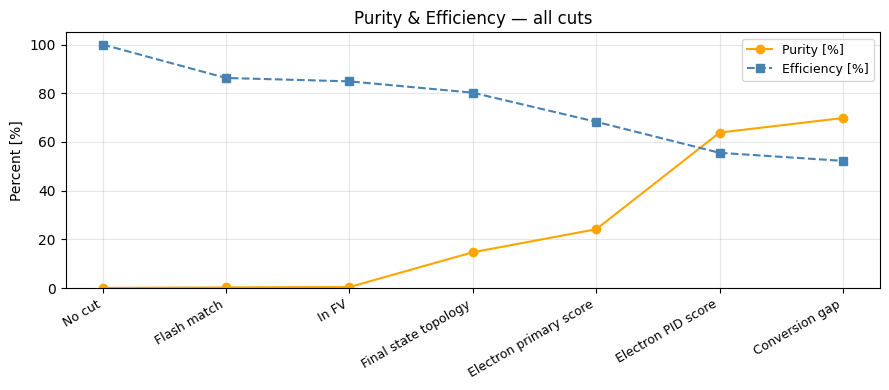

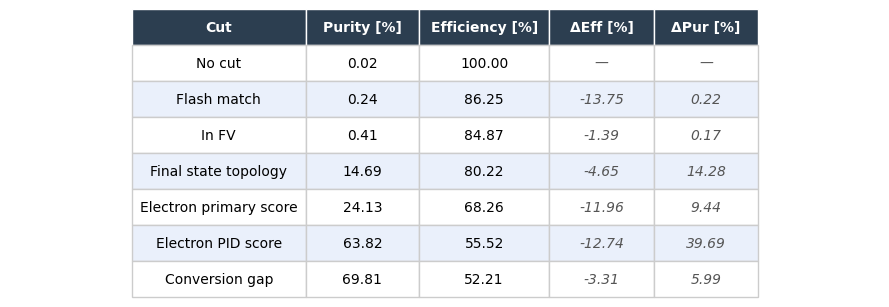

In [64]:
purs_all, effs_all = [], []
for _name in ns.CUT_NAMES_MORE:
    purs_all.append(_row_stats(_stage_idx_qual[_name])[1])
    effs_all.append(_row_stats(_stage_idx_qual[_name])[2])

fig_pe, ax_pe = plt.subplots(figsize=(9, 4))
ax_pe.plot(ns.CUT_LABELS_MORE, [p * 100 for p in purs_all], "o-",  color="orange",    label="Purity [%]")
ax_pe.plot(ns.CUT_LABELS_MORE, [e * 100 for e in effs_all], "s--", color="steelblue", label="Efficiency [%]")
ax_pe.set_ylim(0, 105)
ax_pe.set_xticks(range(len(ns.CUT_LABELS_MORE)))
ax_pe.set_xticklabels(ns.CUT_LABELS_MORE, rotation=30, ha="right", fontsize=9)
ax_pe.set_ylabel("Percent [%]")
ax_pe.set_title("Purity & Efficiency — all cuts")
ax_pe.legend(fontsize=9)
ax_pe.grid(alpha=0.3)
plt.tight_layout()
plt.show()
nh.save_plot("cutflow_pur_eff_final", fig=fig_pe, folder_name=PLOT_DIR)

fig_tab, ax_tab = plt.subplots(figsize=(9, 3.2))
nh.create_purity_efficiency_table(purs_all, effs_all, ns.CUT_LABELS_MORE, ax_tab)
fig_tab.tight_layout()
plt.show()
nh.save_plot("pur_eff_table_all_final", fig=fig_tab, folder_name=PLOT_DIR)

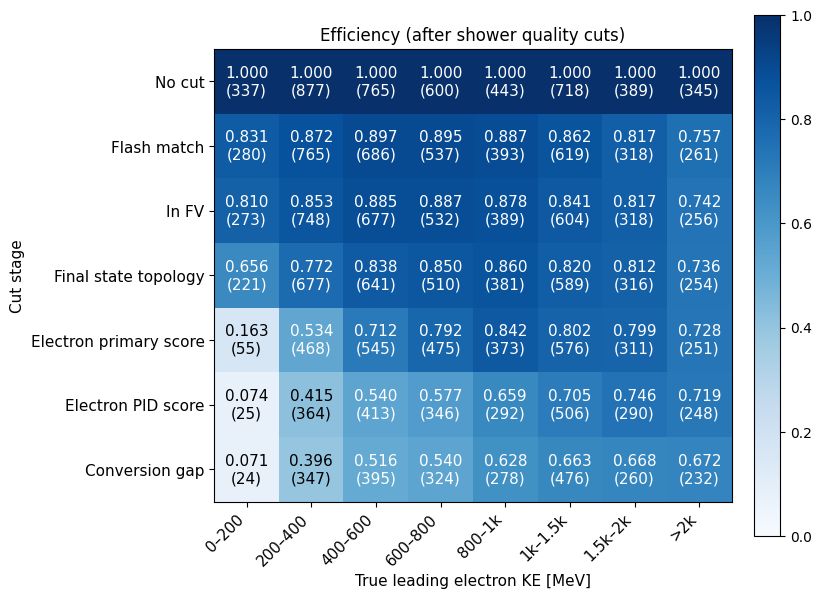

In [65]:
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_bins = len(ke_bins_c) - 1
n_cuts = len(ns.CUT_NAMES_MORE)

ke_vals_sq  = truth_info["true_leading_e_ke"].fillna(-999).values
sig_vals_sq = truth_info["is_true_signal"].values
stage_sel_sq = {
    cut_name: truth_info.index.isin(_stage_idx_qual[cut_name])
    for cut_name in ns.CUT_NAMES_MORE
}

eff_matrix   = np.zeros((n_bins, n_cuts))
count_matrix = np.zeros((n_bins, n_cuts))
for ci, cut_name in enumerate(ns.CUT_NAMES_MORE):
    reco_sel = stage_sel_sq[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals_sq >= lo) & (ke_vals_sq < hi)
        sig_total    = (in_bin & sig_vals_sq).sum()
        sig_selected = (in_bin & sig_vals_sq & reco_sel).sum()
        eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    eff_matrix, count_matrix,
    bin_values       = np.arange(n_bins),
    bin_labels       = ke_bin_labels,
    cut_labels       = ns.CUT_LABELS_MORE,
    remove_dummy_col = False,
    xlabel           = "True leading electron KE [MeV]",
    title            = "Efficiency (after shower quality cuts)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke_final", fig=fig, folder_name=PLOT_DIR)

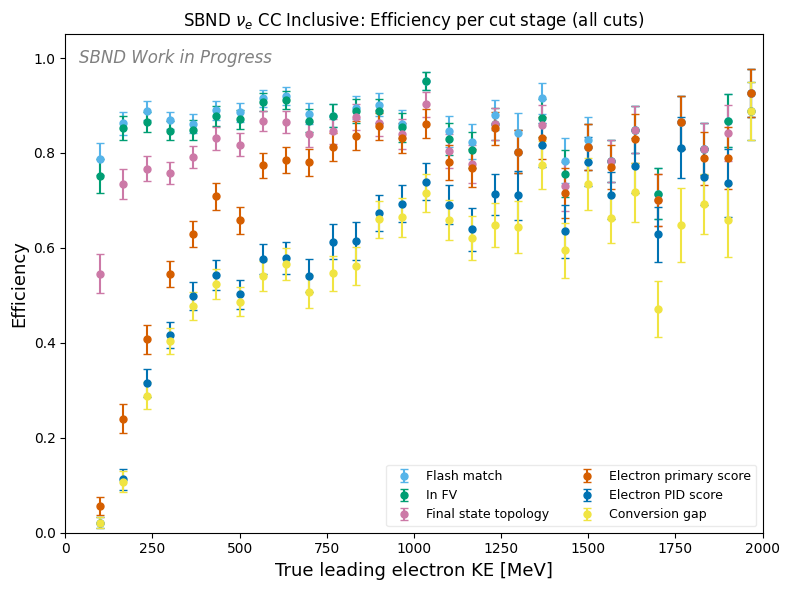

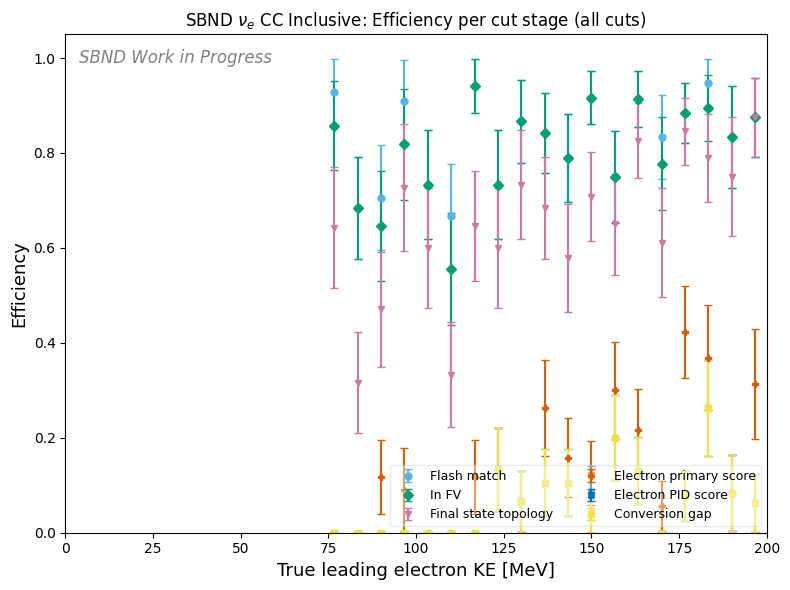

In [66]:
ke_bins_eff  = np.linspace(0, 2000, 31)
all_true_ke  = truth_info["true_leading_e_ke"].fillna(-999).values
all_sig_mask = truth_info["is_true_signal"].values

# Enough distinct colours for all CUT_NAMES_MORE entries (typically ~10)
_palette_sq = [
    "#E69F00", "#56B4E9", "#009E73", "#CC79A7",
    "#D55E00", "#0072B2", "#F0E442", "#8B4513",
    "#FF6347", "#6A5ACD",
]
_markers_sq = ["o", "o", "o", "o", "o", "o", "o", "o", "o", "o"]

fig_eff, ax_eff = plt.subplots(figsize=(8, 6))

for (cname, clabel), color, marker in zip(
        zip(ns.CUT_NAMES_MORE, ns.CUT_LABELS_MORE), _palette_sq, _markers_sq):

    if cname == "precut":
        continue                  # skip "no cut" baseline

    sel_mask = stage_sel_sq[cname]
    centers, _, effs_b, counts_b = nh.pur_eff_binned(
        values   = all_true_ke,
        bins     = ke_bins_eff,
        sel_mask = sel_mask,
        sig_mask = all_sig_mask,
    )
    eff_err = np.sqrt(effs_b * (1 - effs_b) / np.maximum(counts_b, 1))
    ax_eff.errorbar(centers, effs_b, yerr=eff_err,
                    fmt=marker, color=color, capsize=3, ms=5,
                    lw=1.5, label=clabel)

ax_eff.set_ylabel("Efficiency", fontsize=13)
ax_eff.set_xlabel("True leading electron KE [MeV]", fontsize=13)
ax_eff.set_ylim(0, 1.05)
ax_eff.set_xlim(ke_bins_eff[0], ke_bins_eff[-1])
ax_eff.legend(fontsize=9, loc="lower right", framealpha=0.4,
              ncol=2)          # two columns keeps the legend compact for ~10 entries
ax_eff.set_title(fr"{TITLE}: Efficiency per cut stage (all cuts)",
                 fontsize=12)
ax_eff.text(0.02, 0.97, "SBND Work in Progress",
            transform=ax_eff.transAxes, fontsize=12, color="gray",
            va="top", style="italic")

plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_all_stages_with_sq", fig=fig_eff, folder_name=PLOT_DIR)


ke_bins_eff  = np.linspace(0, 200, 31)
all_true_ke  = truth_info["true_leading_e_ke"].fillna(-999).values
all_sig_mask = truth_info["is_true_signal"].values

# Enough distinct colours for all CUT_NAMES_MORE entries (typically ~10)
_palette_sq = [
    "#E69F00", "#56B4E9", "#009E73", "#CC79A7",
    "#D55E00", "#0072B2", "#F0E442", "#8B4513",
    "#FF6347", "#6A5ACD",
]
_markers_sq = ["^", "o", "D", "v", "P", "X", "s", "h", "*", "+"]

fig_eff, ax_eff = plt.subplots(figsize=(8, 6))

for (cname, clabel), color, marker in zip(
        zip(ns.CUT_NAMES_MORE, ns.CUT_LABELS_MORE), _palette_sq, _markers_sq):

    if cname == "precut":
        continue                  # skip "no cut" baseline

    sel_mask = stage_sel_sq[cname]
    centers, _, effs_b, counts_b = nh.pur_eff_binned(
        values   = all_true_ke,
        bins     = ke_bins_eff,
        sel_mask = sel_mask,
        sig_mask = all_sig_mask,
    )
    eff_err = np.sqrt(effs_b * (1 - effs_b) / np.maximum(counts_b, 1))
    ax_eff.errorbar(centers, effs_b, yerr=eff_err,
                    fmt=marker, color=color, capsize=3, ms=5,
                    lw=1.5, label=clabel)

ax_eff.set_ylabel("Efficiency", fontsize=13)
ax_eff.set_xlabel("True leading electron KE [MeV]", fontsize=13)
ax_eff.set_ylim(0, 1.05)
ax_eff.set_xlim(ke_bins_eff[0], ke_bins_eff[-1])
ax_eff.legend(fontsize=9, loc="lower right", framealpha=0.4,
              ncol=2)          # two columns keeps the legend compact for ~10 entries
ax_eff.set_title(fr"{TITLE}: Efficiency per cut stage (all cuts)",
                 fontsize=12)
ax_eff.text(0.02, 0.97, "SBND Work in Progress",
            transform=ax_eff.transAxes, fontsize=12, color="gray",
            va="top", style="italic")

plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_all_stages_with_sq_lowKE", fig=fig_eff, folder_name=PLOT_DIR)



### 5-2. Histograms

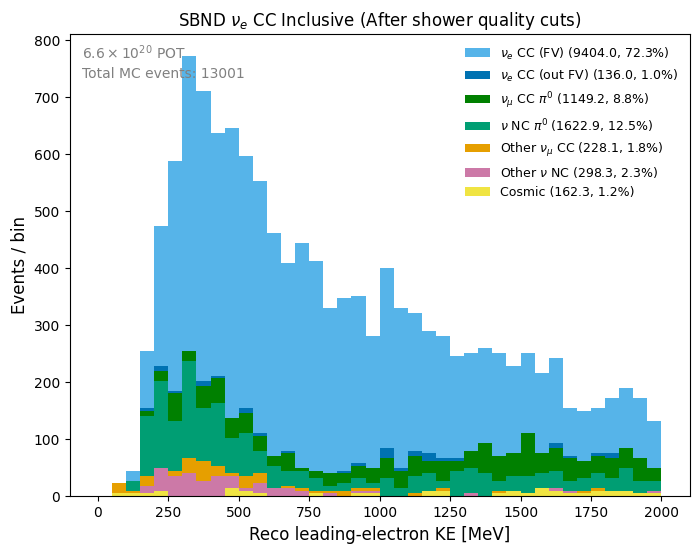

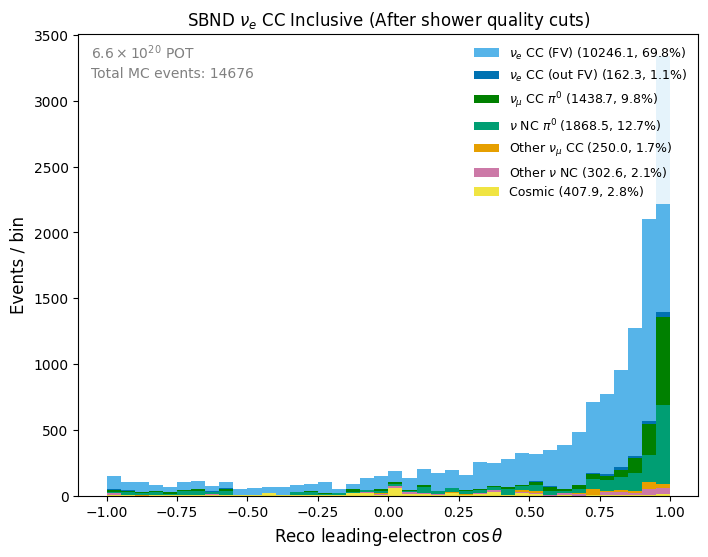

In [67]:
final_col   = f"sel_{ns.CUT_NAMES_MORE[-1]}"
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

def _qual_cat(col, cat):
    mask = sel_qual[final_col] & (sel_qual["truth_cat"] == cat)
    mask = mask & sel_qual["reco_ke"].notna() & sel_qual["reco_costheta"].notna()
    return sel_qual.loc[mask, col].values

fig_ke2, ax_ke2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.linspace(0, 2000, 41),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke_final", fig=fig_ke2, folder_name=PLOT_DIR)

fig_cos2, ax_cos2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta_final", fig=fig_cos2, folder_name=PLOT_DIR)

In [ ]:
%reset -f

In [ ]:
pause